# Анализ заявок и поездок на такси

Цель работы — проанализировать реестр заявок и поездок на такси сотрудников компании и определить:

- структуру заявок, поездок и расходов;
- качество и полноту исходных данных;
- отклонения фактических показателей от предварительных;
- соблюдение сроков подачи транспортного средства;
- причины отмен и незавершённых заявок;
- нетипичные поездки и потенциальные зоны для дополнительного контроля;
- возможные направления оптимизации расходов и процесса транспортного обеспечения.

Анализ включает подготовку и проверку качества данных, исследовательский анализ, анализ плановых и фактических показателей, сроков исполнения и аномальных наблюдений.

# 1. Подготовка и проверка данных
## Загрузка и первичный обзор данных

In [1]:
# На первом этапе загрузим исходный набор данных и изучим его структуру: размер, состав полей, типы данных и примеры записей.

import pandas as pd
import numpy as np

df = pd.read_csv('taxi_dataset.csv')

df.head(5)

C:\Users\User\AppData\Local\Temp\ipykernel_11420\2379577850.py:6: DtypeWarning: Columns (37,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('taxi_dataset.csv')


,Номер заявки,Дата и время создания заявки,Статус поездки,Статус поездки (причина отмены),Вид тарифа,Адрес отправления,Промежуточные адреса,Количество точек в маршруте,"Время ожидания в промежуточной точке, мин",Адрес прибытия,...,Оценка поездки пользователем,ID Совместной поездки,Источник данных,Контрольный срок,Экономия,"Экономия от совместные поездки, руб.","Экономия при указании пассажиров, руб.",ID группы исполнителей,Наименование группы исполнителей,Номер исполнителя
0,OT-0010-00428923,2025-06-16 03:51:53,Поездка завершена,NaN,Эконом,"Новосибирская область, Новосибирск, улица Сере...","Новосибирская область, Новосибирск, Котовского...",3,00:00:00,"Новосибирская область, Новосибирск, Зорге, 219",...,NaN,NaN,WEB,НЕТ,Нет,NaN,NaN,NaN,NaN,Исполнитель 1
1,OT-0010-00428922,2025-06-16 03:49:50,Поездка завершена,NaN,Эконом,"Новосибирская область, Новосибирск, улица Сере...",NaN,2,00:00:00,"Новосибирская область, Новосибирск, Дмитрия Шм...",...,NaN,NaN,WEB,НЕТ,Нет,NaN,NaN,NaN,NaN,Исполнитель 1
2,OT-0002-00765077,2025-06-16 03:17:42,Поездка завершена,NaN,Эконом,"Новосибирская область, Новосибирск, Горский ми...",NaN,2,00:00:00,"Новосибирская область, Новосибирск, проспект Д...",...,NaN,2cbf79b0-b37d-48f7-b143-fe9d25a44bc4,MOBILE_IOS,НЕТ,Нет,NaN,NaN,NaN,NaN,Исполнитель 22
3,OT-0008-00495909,2025-06-15 23:14:34,Поездка завершена,NaN,Эконом,"Санкт-Петербург, Шафировский проспект, 2",NaN,2,00:00:00,"Ленинградская область, Кудрово, Европейский пр...",...,NaN,NaN,MOBILE_ANDROID,НЕТ,Нет,NaN,NaN,NaN,NaN,Исполнитель 6
4,OT-0002-00765076,2025-06-15 23:06:13,Поездка завершена,NaN,Эконом,"Республика Татарстан, Казань, Бутлерова, 44",NaN,2,00:00:00,"Республика Татарстан (Татарстан), Казань, улиц...",...,NaN,NaN,WEB,НЕТ,Нет,NaN,NaN,NaN,NaN,Исполнитель 41


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334518 entries, 0 to 334517
Data columns (total 46 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   Номер заявки                                                    334518 non-null  object 
 1   Дата и время создания заявки                                    334518 non-null  object 
 2   Статус поездки                                                  334518 non-null  object 
 3   Статус поездки (причина отмены)                                 46121 non-null   object 
 4   Вид тарифа                                                      334518 non-null  object 
 5   Адрес отправления                                               334518 non-null  object 
 6   Промежуточные адреса                                            50181 non-null   object 
 7   Количество точек в маршруте           

In [3]:
# Структура и полный список колонок

print("Размер датасета:", df.shape)

print("\nСписок колонок:")
for i, col in enumerate(df.columns):
    print(i, col)

Размер датасета: (334518, 46)

Список колонок:
0 Номер заявки
1 Дата и время создания заявки
2 Статус поездки
3 Статус поездки (причина отмены)
4 Вид тарифа
5 Адрес отправления
6 Промежуточные адреса
7 Количество точек в маршруте
8 Время ожидания в промежуточной точке, мин
9 Адрес прибытия
10 Дата и время выполнения заявки
11 Желаемая дата отправления
12 Контрольный срок подачи ТС (расчетный)
13 Фактическое дата и время прибытия ТС
14 ID заявителя
15 Количество забронированных мест (без учета водителя)
16 Цель поездки
17 ID подразделения
18 Должность пассажира
19 ID заявителя.1
20 ID заявителя.2
21 Предварительный километраж в заявке, км
22 Фактический километраж в поездке, км
23 Предварительная стоимость в заявке, руб
24 Стоимость минимальной поездки на такси
25 Фактическая стоимость в поездке, руб
26 Предварительное время в заявке, час/мин
27 Фактическое время поездки в поездке, час/мин
28 Суммарное фактическое время ожидания, мин.
29 Инициатор совместной поездки
30 Количество присое

In [88]:
for i in range(20, 43):
    print(i, df.columns[i])

20 ID заявителя.2
21 Предварительный километраж в заявке, км
22 Фактический километраж в поездке, км
23 Предварительная стоимость в заявке, руб
24 Стоимость минимальной поездки на такси
25 Фактическая стоимость в поездке, руб
26 Предварительное время в заявке, час/мин
27 Фактическое время поездки в поездке, час/мин
28 Суммарное фактическое время ожидания, мин.
29 Инициатор совместной поездки
30 Количество присоединенных заявок
31 Сумма к списанию с лимита, руб
32 Экономия бюджета для подразделения, руб
33 Финансовый эффект для организации (присоединённые заявки), руб
34 Финансовый эффект для организации (забронированные места), руб
35 Итоговый финансовый эффект для организации, руб
36 Оценка поездки пользователем
37 ID Совместной поездки
38 Источник данных
39 Контрольный срок
40 Экономия
41 Экономия от совместные поездки, руб.
42 Экономия при указании пассажиров, руб.


Набор содержит **334 518 записей и 46 признаков**. На данном этапе предполагается, что одна строка соответствует одной заявке; уникальность поля `Номер заявки` будет проверена отдельно.

В данных представлены несколько основных групп признаков:

- идентификаторы заявки, заявителя, подразделения и исполнителя;
- статус заявки и причина отмены;
- параметры маршрута и тарифа;
- плановые и фактические показатели километража, стоимости и времени;
- временные характеристики создания и исполнения заявки;
- показатели совместных поездок и финансового эффекта;
- дополнительные характеристики исполнения и оценки поездки.

При первичном просмотре видно, что поля с датой и временем, а также некоторые показатели длительности представлены типом `object`. Корректность типов и необходимость преобразования будут проверены на этапе подготовки данных.

## Проверка качества данных

Перед проведением анализа оценим качество исходных данных:

- полноту заполнения признаков;
- наличие дубликатов и уникальность заявок;
- типы данных и количество уникальных значений;
- однородность категориальных признаков;
- логическую согласованность связанных полей.

Пропуски и некорректные значения не будут удаляться или заменяться автоматически: способ обработки определяется с учетом смысла конкретного признака.


1.1. Пропущенные значения

Оценим количество и долю пропущенных значений по каждому признаку. Наличие пропуска само по себе не означает ошибку: часть пропусков может быть обусловлена бизнес-логикой процесса.

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

missing = missing[missing["missing_count"] > 0]
missing = missing.sort_values("missing_pct", ascending=False)

display(missing)

,missing_count,missing_pct
"Экономия от совместные поездки, руб.",334518,100.00
"Экономия при указании пассажиров, руб.",334518,100.00
ID группы исполнителей,325720,97.37
Наименование группы исполнителей,325720,97.37
Оценка поездки пользователем,291665,87.19
Статус поездки (причина отмены),288397,86.21
Промежуточные адреса,284337,85.00
"Финансовый эффект для организации (присоединённые заявки), руб",257851,77.08
ID Совместной поездки,245501,73.39
"Фактическое время поездки в поездке, час/мин",170476,50.96


1.2. Уникальные значения.

Проверим типы данных и количество уникальных заполненных значений. Это позволит выявить признаки с низкой кардинальностью, потенциальные идентификаторы и категориальные поля, а также обратить внимание на признаки, тип данных которых может не соответствовать их содержимому.

In [6]:
unique = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique()
})

unique = unique.sort_values("n_unique")

display(unique)

,dtype,n_unique
"Экономия от совместные поездки, руб.",float64,0
"Экономия при указании пассажиров, руб.",float64,0
Количество присоединенных заявок,int64,2
Инициатор совместной поездки,object,2
Экономия,object,2
Контрольный срок,object,2
Источник данных,object,3
Статус поездки (причина отмены),object,4
Оценка поездки пользователем,float64,5
"Финансовый эффект для организации (присоединённые заявки), руб",float64,8


1.3. Проверка дубликатов и уникальности заявок

Проверим как полное дублирование строк, так и повторение номера заявки. Эти проверки разделены, поскольку повторение идентификатора заявки не обязательно означает полное дублирование записи.

In [7]:

full_duplicates = df.duplicated().sum()
print("Полных дублей строк:", full_duplicates)

duplicate_orders = df["Номер заявки"].duplicated().sum()
print("Количество повторяющихся номеров заявок:", duplicate_orders)

Полных дублей строк: 0
Количество повторяющихся номеров заявок: 0


Полные дубликаты строк и повторяющиеся номера заявок отсутствуют. Следовательно, каждая строка соответствует отдельной уникальной заявке, и удаление записей по признаку дублирования не требуется.

1.4. Проверка идентификатора заявителя

В наборе данных присутствуют три поля: `ID заявителя`, `ID заявителя.1` и `ID заявителя.2`. Проверим, являются ли они полными дубликатами друг друга.

In [8]:
print(
    "ID заявителя и ID заявителя.1 совпадают:",
    df["ID заявителя"].equals(df["ID заявителя.1"])
)

print(
    "ID заявителя и ID заявителя.2 совпадают:",
    df["ID заявителя"].equals(df["ID заявителя.2"])
)

print(
    "ID заявителя.1 и ID заявителя.2 совпадают:",
    df["ID заявителя.1"].equals(df["ID заявителя.2"])
)

ID заявителя и ID заявителя.1 совпадают: False
ID заявителя и ID заявителя.2 совпадают: False
ID заявителя.1 и ID заявителя.2 совпадают: False


Ни одна пара столбцов не совпадает полностью. Кроме того, количество уникальных значений в них различается, а в `ID заявителя.2` присутствуют пропуски.

Следовательно, считать поля техническими дубликатами и удалять их только на основании названия нельзя. При отсутствии описания исходной схемы данных их смысл однозначно определить невозможно, поэтому на данном этапе все три признака сохраняются.

1.5. Категориальные признаки

Проверим распределение основных категориальных признаков и однородность их значений. Особое внимание уделим различиям, которые могут быть вызваны опечатками, лишними пробелами или различным написанием одной категории.

На данном этапе категории не объединяются автоматически: потенциальные совпадения должны быть подтверждены их смыслом.

In [93]:
categorical_cols = [
    "Статус поездки",
    "Статус поездки (причина отмены)",
    "Вид тарифа"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))

print("\nЦель поездки")
print("Количество уникальных значений:", df["Цель поездки"].nunique())
display(df["Цель поездки"].value_counts(dropna=False).head(20))


Статус поездки
Статус поездки
Поездка завершена                       286727
Отменено                                 46538
Согласована                                537
Ожидайте назначения водителя               330
Водитель ожидает в точке отправления       315
На согласовании                             31
Поездка началась                            19
Водитель назначен                           15
Водитель в пути                              6
Name: count, dtype: int64

Статус поездки (причина отмены)
Статус поездки (причина отмены)
NaN                                  288397
Отмена пользователем                  27175
Не согласовано по истечению срока      9354
Отмена  диспетчером                    8023
Не согласовано                         1569
Name: count, dtype: int64

Вид тарифа
Вид тарифа
Эконом                       307205
Комфорт                       24181
Автобус от 10 до 21 места       734
Служебный                       605
Автобус от 22 до 41 места       538
Автобу

Цель поездки
Доставка сотрудников в ночное время                           150778
Встречи с клиентами                                            77883
Доставка работников в ночное время                             25060
Доставка сотрудников  в ночное время                           24588
Производственные (банковские) мероприятия                      11649
Выезды в государственные органы                                 8668
Доставка подменного фонда работников в ВСП и обратно            6329
Доставка банковских карт                                        5841
Встречи с контрагентами                                         5313
Проведение контрольных процедур                                 4009
Доставка сотрудников в ночное времяя                            3597
Гемба                                                           2965
Выезды для участия в коллегиальных органах/рабочих группах      2733
Проведение наставничества ВСП                                   1246
Выезды к должникам Ба

В поле `Статус поездки` обнаружено 9 различных состояний. Основную часть составляют завершённые и отменённые заявки, однако присутствуют также промежуточные статусы процесса исполнения. Поэтому при дальнейшем анализе необходимо отдельно определить правила классификации завершённых, отменённых и незавершённых заявок.

В поле `Статус поездки (причина отмены)` представлены четыре причины отмены. Большая доля пропусков в данном признаке ожидаема для заявок, которые не были отменены; логическая согласованность причины отмены со статусом заявки будет проверена отдельно.

В поле `Цель поездки` обнаружены признаки неоднородности справочника. Например, встречаются значения:

- `Доставка работников в ночное время`;
- `Доставка сотрудников  в ночное время`;
- `Доставка сотрудников в ночное времяя`.

Различия обусловлены лишними пробелами и опечаткой и могут приводить к искусственному разделению одной категории при агрегировании. Перед анализом справочник необходимо нормализовать.

При этом семантически похожие, но не идентичные категории (например, `Доставка сотрудников...` и `Доставка работников...`) без дополнительной информации автоматически объединяться не будут.

1.6. Согласованность статуса поездки и причины отмены

Поле с причиной отмены содержит большое количество пропусков. Само по себе это не является ошибкой, поскольку причина отмены должна быть релевантна прежде всего для отменённых заявок.

Проверим:
- сколько всего отменённых заявок;
- у скольких отменённых заявок отсутствует причина;
- встречается ли причина отмены у заявок с другими статусами.

In [10]:
cancelled = df["Статус поездки"] == "Отменено"

cancelled_total = cancelled.sum()

cancelled_without_reason = df.loc[
    cancelled,
    "Статус поездки (причина отмены)"
].isna().sum()

reason_for_not_cancelled = df.loc[
    ~cancelled,
    "Статус поездки (причина отмены)"
].notna().sum()

print("Отменённых заявок:", cancelled_total)
print("Отменённых заявок без причины:", cancelled_without_reason)
print("Неотменённых заявок с причиной отмены:", reason_for_not_cancelled)

Отменённых заявок: 46538
Отменённых заявок без причины: 507
Неотменённых заявок с причиной отмены: 90


1.7. Проверка промежуточных адресов

Здесь у нас 85% пропусков, но мы предполагаем, что отсутствие промежуточного адреса может быть нормальным. У нас есть подходящее поле для проверки:

Количество точек в маршруте.

In [95]:
print(
    df["Количество точек в маршруте"]
    .value_counts()
    .sort_index()
)

Количество точек в маршруте
2     284337
3      28010
4      10992
5       9938
6        452
7        249
8        110
9         81
10       109
11        36
12        51
13        31
14        14
15        14
16         5
17        17
18         4
19         3
20         5
21         6
22         3
23         9
24         4
25         2
26         3
27        10
28         7
30         1
31         4
32         2
33         1
34         3
36         3
38         1
41         1
Name: count, dtype: int64


1.8. Полностью незаполненные признаки

В ходе анализа пропусков обнаружены два признака со 100% отсутствующих значений. Проверим это отдельно перед принятием решения об их дальнейшем использовании.

In [12]:
empty_cols = [
    "Экономия от совместные поездки, руб.",
    "Экономия при указании пассажиров, руб."
]

for col in empty_cols:
    print(
        col,
        "- заполненных значений:",
        df[col].notna().sum()
    )

Экономия от совместные поездки, руб. - заполненных значений: 0
Экономия при указании пассажиров, руб. - заполненных значений: 0


Оба признака полностью не заполнены и не содержат информации для анализа. На этапе подготовки данных они будут исключены из рабочего набора.

При этом наличие других признаков, связанных с совместными поездками и финансовым эффектом, позволяет отдельно проверить возможность анализа данного направления. 

Промежуточные адреса отсутствуют в 284 337 строках;
Количество точек в маршруте = 2, тоже ровно в 284 337 строках. 

Маршрут из двух точек, вероятно, состоит только из отправления и прибытия. Но прежде чем утверждать, что соответствие точное на уровне строк, нужно проверить:

In [13]:
route_check = (
    (df["Количество точек в маршруте"] == 2)
    == df["Промежуточные адреса"].isna()
)

print(
    "Строк, где количество точек согласуется с наличием промежуточных адресов:",
    route_check.sum()
)

print(
    "Несогласованных строк:",
    (~route_check).sum()
)

Строк, где количество точек согласуется с наличием промежуточных адресов: 334518
Несогласованных строк: 0


### Итоги первичной проверки качества данных

По результатам первичной проверки выявлены следующие особенности данных:

1. **Дубликаты отсутствуют.** Полные дубликаты строк и повторяющиеся значения `Номер заявки` не обнаружены. Каждая из 334 518 строк соответствует отдельной уникальной заявке.

2. **Пропуски имеют различную природу и не требуют автоматического удаления.** Часть отсутствующих значений обусловлена бизнес-логикой соответствующих признаков, поэтому дальнейшая обработка пропусков будет выполняться с учётом их содержания.

3. **В данных об отменах обнаружены отдельные логические несоответствия.** Из 46 538 отменённых заявок у 507 (около 1,1%) отсутствует причина отмены. Одновременно у 90 заявок с другими статусами причина отмены заполнена. Эти особенности необходимо учитывать при анализе причин отмен.

4. **Пропуски в поле `Промежуточные адреса` являются структурными.** Все 284 337 записей без промежуточного адреса соответствуют маршрутам из двух точек. Несогласованных записей не обнаружено, поэтому такие пропуски не рассматриваются как ошибка качества данных.

5. **Два признака полностью не заполнены:** `Экономия от совместные поездки, руб.` и `Экономия при указании пассажиров, руб.`. Они не содержат аналитической информации и будут исключены из рабочего набора данных. При этом в наборе присутствуют другие показатели совместных поездок и финансового эффекта, поэтому возможность анализа данного направления будет оценена отдельно.

6. **В категориальных данных выявлена неоднородность написания значений.** Например, в поле `Цель поездки` встречаются категории, различающиеся лишними пробелами и опечатками. Перед агрегированием такие технические различия необходимо нормализовать. Семантически похожие категории без подтверждения их эквивалентности автоматически объединяться не будут.

7. **Поля идентификаторов заявителя не являются дубликатами.** `ID заявителя`, `ID заявителя.1` и `ID заявителя.2` различаются по значениям и количеству уникальных идентификаторов. При отсутствии описания исходной схемы их бизнес-смысл однозначно определить невозможно, поэтому поля сохраняются без дополнительной интерпретации.

8. **Часть типов данных требует преобразования.** Временные признаки представлены типом `object`, а некоторые показатели длительности требуют дополнительной проверки формата перед использованием в расчётах.

Таким образом, на этапе первичной проверки не выявлено проблем, требующих массового удаления наблюдений. Основные задачи следующего этапа — преобразование типов данных, нормализация категориальных значений, обработка выявленных особенностей и проверка логической согласованности временных и числовых показателей.

## 2. Подготовка и преобразование данных

На основе результатов первичной проверки подготовим данные к дальнейшему анализу.

На данном этапе необходимо:

- сохранить исходные данные без изменений и создать рабочую копию;
- исключить полностью незаполненные признаки;
- привести даты и временные показатели к форматам, пригодным для расчётов;
- нормализовать технические различия в категориальных значениях;
- проверить корректность числовых показателей;
- проверить логическую последовательность временных событий.

Все преобразования выполняются только после проверки исходных значений, чтобы избежать потери или некорректной интерпретации данных.

2.1. Создание рабочего набора данных

Для подготовки данных создадим отдельную копию исходного набора. Это позволит сохранить исходные данные без изменений и выполнять дальнейшие преобразования только в рабочем DataFrame.

In [14]:
df_clean = df.copy()

print("Размер исходного набора:", df.shape)
print("Размер рабочего набора:", df_clean.shape)

Размер исходного набора: (334518, 46)
Размер рабочего набора: (334518, 46)


2.2. Исключение полностью незаполненных признаков

На этапе проверки качества данных были обнаружены два признака со 100% пропущенных значений. Поскольку они не содержат информации, исключим их из рабочего набора данных.

In [15]:
empty_cols = [
    "Экономия от совместные поездки, руб.",
    "Экономия при указании пассажиров, руб."
]

df_clean = df_clean.drop(columns=empty_cols)

print("Размер рабочего набора после удаления:", df_clean.shape)

Размер рабочего набора после удаления: (334518, 44)


Полностью незаполненные признаки исключены из рабочего набора. Количество наблюдений не изменилось.

2.3. Преобразование временных признаков

Временные характеристики поездок загружены как строки (`object`). Для расчёта интервалов и анализа сроков исполнения их необходимо преобразовать в формат `datetime`.

Перед преобразованием проверим фактический формат заполненных значений и наличие значений, которые не удаётся интерпретировать как дату и время.

In [100]:
date_cols = [
    "Дата и время создания заявки",
    "Дата и время выполнения заявки",
    "Желаемая дата отправления",
    "Контрольный срок подачи ТС (расчетный)",
    "Фактическое дата и время прибытия ТС"
]

for col in date_cols:
    print(f"\n{col}")
    print(df_clean[col].dropna().head(5).tolist())


Дата и время создания заявки
[Timestamp('2025-06-16 03:51:53'), Timestamp('2025-06-16 03:49:50'), Timestamp('2025-06-16 03:17:42'), Timestamp('2025-06-15 23:14:34'), Timestamp('2025-06-15 23:06:13')]

Дата и время выполнения заявки
[Timestamp('2025-06-16 04:49:01'), Timestamp('2025-06-16 04:29:02'), Timestamp('2025-06-16 03:55:07'), Timestamp('2025-06-16 00:19:01'), Timestamp('2025-06-15 23:41:01')]

Желаемая дата отправления
[Timestamp('2025-06-16 03:56:53'), Timestamp('2025-06-16 03:54:50'), Timestamp('2025-06-16 03:22:42'), Timestamp('2025-06-15 23:55:00'), Timestamp('2025-06-15 23:11:13')]

Контрольный срок подачи ТС (расчетный)
[Timestamp('2025-06-16 05:07:03'), Timestamp('2025-06-16 05:06:57'), Timestamp('2025-06-16 04:32:48'), Timestamp('2025-06-16 00:29:39'), Timestamp('2025-06-16 00:21:18')]

Фактическое дата и время прибытия ТС
[Timestamp('2025-06-16 04:13:07'), Timestamp('2025-06-16 04:08:07'), Timestamp('2025-06-16 03:23:17'), Timestamp('2025-06-15 23:51:51'), Timestamp('2

In [17]:
for col in date_cols:
    converted = pd.to_datetime(
        df_clean[col],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    invalid_count = (
        df_clean[col].notna() & converted.isna()
    ).sum()

    print(col, "- некорректных значений:", invalid_count)

Дата и время создания заявки - некорректных значений: 0
Дата и время выполнения заявки - некорректных значений: 0
Желаемая дата отправления - некорректных значений: 0
Контрольный срок подачи ТС (расчетный) - некорректных значений: 0
Фактическое дата и время прибытия ТС - некорректных значений: 0


In [18]:
for col in date_cols:
    df_clean[col] = pd.to_datetime(
        df_clean[col],
        format="%Y-%m-%d %H:%M:%S"
    )
    
print(df_clean[date_cols].dtypes)

Дата и время создания заявки              datetime64[ns]
Дата и время выполнения заявки            datetime64[ns]
Желаемая дата отправления                 datetime64[ns]
Контрольный срок подачи ТС (расчетный)    datetime64[ns]
Фактическое дата и время прибытия ТС      datetime64[ns]
dtype: object


Проверка не выявила заполненных значений, не соответствующих формату даты и времени. Пять временных признаков преобразованы из строкового типа `object` в `datetime64[ns]`. Исходные пропуски при преобразовании сохранены.

2.4. Проверка показателей длительности

В наборе присутствуют несколько признаков, характеризующих продолжительность поездки и ожидания. При этом они имеют разные типы данных (`int64`, `float64`, `object`).

Перед использованием этих показателей в расчётах необходимо определить формат хранения значений и убедиться в корректности их интерпретации.

In [19]:
duration_cols = [
    "Предварительное время в заявке, час/мин",
    "Фактическое время поездки в поездке, час/мин",
    "Время ожидания в промежуточной точке, мин",
    "Суммарное фактическое время ожидания, мин."
]

for col in duration_cols:
    print(f"\n{col}")
    print("Тип колонки:", df_clean[col].dtype)
    print("Примеры:", df_clean[col].dropna().head(10).tolist())

    print("Типы значений:")
    print(df_clean[col].dropna().map(type).value_counts())


Предварительное время в заявке, час/мин
Тип колонки: int64
Примеры: [32, 20, 14, 29, 13, 13, 5, 11, 7, 15]
Типы значений:
Предварительное время в заявке, час/мин
<class 'int'>    334518
Name: count, dtype: int64

Фактическое время поездки в поездке, час/мин
Тип колонки: object
Примеры: ['00:14:00', '00:00:00', '00:11:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:20:00', '00:00:00']
Типы значений:
Фактическое время поездки в поездке, час/мин
<class 'str'>    164042
Name: count, dtype: int64

Время ожидания в промежуточной точке, мин
Тип колонки: object
Примеры: ['00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00', '00:00:00']
Типы значений:
Время ожидания в промежуточной точке, мин
<class 'str'>    334518
Name: count, dtype: int64

Суммарное фактическое время ожидания, мин.
Тип колонки: float64
Примеры: [1.0, 5.0, 0.0, 0.0, 0.0, 11.0, 0.0, 0.0, 0.0, 0.0]
Типы значений:
Суммарное фактическое время ожидания, ми

In [20]:
for col in duration_cols:
    print(f"\n{col}")
    print(df_clean[col].value_counts(dropna=False).head(15))


Предварительное время в заявке, час/мин
Предварительное время в заявке, час/мин
12    13202
14    13142
11    12913
15    12769
13    12692
10    12186
9     11802
16    11722
17    10879
8     10395
18    10346
19    10060
20     9684
21     9661
22     9403
Name: count, dtype: int64

Фактическое время поездки в поездке, час/мин
Фактическое время поездки в поездке, час/мин
NaN         170476
00:00:00     69098
03:00:00      9488
00:11:00      3241
00:12:00      3144
00:10:00      3006
00:14:00      2819
00:15:00      2746
00:13:00      2734
00:09:00      2503
00:16:00      2451
00:18:00      2086
00:20:00      2079
00:17:00      2045
00:05:00      1993
Name: count, dtype: int64

Время ожидания в промежуточной точке, мин
Время ожидания в промежуточной точке, мин
00:00:00    325802
00:30:00      1210
00:15:00      1129
01:00:00      1059
00:10:00       904
00:20:00       883
00:40:00       538
02:00:00       396
00:05:00       329
03:00:00       297
04:00:00       250
01:30:00       21

2.4.1. Проверка формата строковых длительностей

Два показателя длительности представлены строками. Несмотря на указание единицы измерения `мин` в названии одного из признаков, значения имеют формат времени. Перед преобразованием проверим, все ли заполненные значения соответствуют единому формату `HH:MM:SS`.

In [21]:
time_string_cols = [
    "Фактическое время поездки в поездке, час/мин",
    "Время ожидания в промежуточной точке, мин"
]

for col in time_string_cols:
    valid_format = df_clean[col].str.match(
        r"^\d+:\d{2}:\d{2}$",
        na=False
    )

    invalid_count = (
        df_clean[col].notna() & ~valid_format
    ).sum()

    print(col)
    print("Заполненных значений:", df_clean[col].notna().sum())
    print("Не соответствуют формату:", invalid_count)

numeric_duration_cols = [
    "Предварительное время в заявке, час/мин",
    "Суммарное фактическое время ожидания, мин."
]

for col in numeric_duration_cols:
    print(f"\n{col}")
    print("Минимум:", df_clean[col].min())
    print("Максимум:", df_clean[col].max())
    print("Нулевых значений:", (df_clean[col] == 0).sum())
    print("Отрицательных значений:", (df_clean[col] < 0).sum())

Фактическое время поездки в поездке, час/мин
Заполненных значений: 164042
Не соответствуют формату: 0
Время ожидания в промежуточной точке, мин
Заполненных значений: 334518
Не соответствуют формату: 0

Предварительное время в заявке, час/мин
Минимум: 0
Максимум: 3145
Нулевых значений: 86
Отрицательных значений: 0

Суммарное фактическое время ожидания, мин.
Минимум: -8921001.0
Максимум: 18000000.0
Нулевых значений: 192562
Отрицательных значений: 4


2.4.2. Преобразование длительностей

Строковые показатели длительности имеют единый формат `HH:MM:SS`, поэтому их можно преобразовать в числовое представление.

Для дальнейшего анализа все временные интервалы приведём к минутам. Исходные признаки сохраняются, а преобразованные значения будут записаны в отдельные колонки.

In [22]:
df_clean["Фактическое время поездки, мин"] = (
    pd.to_timedelta(
        df_clean["Фактическое время поездки в поездке, час/мин"]
    ).dt.total_seconds() / 60
)

df_clean["Время ожидания в промежуточной точке, мин_clean"] = (
    pd.to_timedelta(
        df_clean["Время ожидания в промежуточной точке, мин"]
    ).dt.total_seconds() / 60
)

duration_check_cols = [
    "Предварительное время в заявке, час/мин",
    "Фактическое время поездки, мин",
    "Время ожидания в промежуточной точке, мин_clean",
    "Суммарное фактическое время ожидания, мин."
]

df_clean[duration_check_cols].describe()

,"Предварительное время в заявке, час/мин","Фактическое время поездки, мин","Время ожидания в промежуточной точке, мин_clean","Суммарное фактическое время ожидания, мин."
count,334518.000000,164042.000000,334518.000000,2.366570e+05
mean,28.396311,31.644073,1.716721,2.090905e+02
std,41.437695,59.361705,18.268553,6.709126e+04
min,0.000000,0.000000,0.000000,-8.921001e+06
25%,12.000000,0.000000,0.000000,0.000000e+00
50%,20.000000,10.000000,0.000000,0.000000e+00
75%,30.000000,29.000000,0.000000,0.000000e+00
max,3145.000000,1378.000000,2580.000000,1.800000e+07


In [23]:
for col in duration_check_cols:
    print(f"\n{col}")
    print("Пропусков:", df_clean[col].isna().sum())
    print("Минимум:", df_clean[col].min())
    print("Максимум:", df_clean[col].max())


Предварительное время в заявке, час/мин
Пропусков: 0
Минимум: 0
Максимум: 3145

Фактическое время поездки, мин
Пропусков: 170476
Минимум: 0.0
Максимум: 1378.0

Время ожидания в промежуточной точке, мин_clean
Пропусков: 0
Минимум: 0.0
Максимум: 2580.0

Суммарное фактическое время ожидания, мин.
Пропусков: 97861
Минимум: -8921001.0
Максимум: 18000000.0


#### Результаты проверки показателей длительности

По результатам проверки и преобразования временных показателей установлено следующее:

- значения `Фактическое время поездки в поездке, час/мин` и `Время ожидания в промежуточной точке, мин` представлены строками единого формата `HH:MM:SS`. Для дальнейшего анализа они преобразованы в минуты и сохранены в отдельных аналитических признаках;

- `Предварительное время в заявке, час/мин` представлено целыми числовыми значениями, не содержит пропусков и отрицательных значений. В данных присутствуют 86 нулевых значений, а максимальное значение составляет 3145. Причины появления нулевых и высоких значений на данном этапе не определены — они будут дополнительно рассмотрены при анализе аномалий;

- `Фактическое время поездки` содержит 170 476 пропусков (50,96% наблюдений). Среди заполненных значений минимальное значение составляет 0 минут, максимальное — 1378 минут. Связь пропусков и нулевых значений со статусами и особенностями выполнения заявок будет проверена на следующих этапах анализа;

- `Время ожидания в промежуточной точке` после преобразования принимает значения от 0 до 2580 минут. Медиана и третий квартиль равны 0, то есть как минимум 75% наблюдений имеют нулевое значение данного показателя. Высокие значения будут дополнительно рассмотрены при анализе аномалий;

- в поле `Суммарное фактическое время ожидания, мин.` обнаружены 97 861 пропуск, а также отрицательные и экстремально большие значения. Минимальное значение составляет -8 921 001 минуту, максимальное — 18 000 000 минут. Такие значения выглядят логически сомнительными для показателя длительности ожидания, однако на этапе подготовки данных они не удаляются автоматически и будут отдельно исследованы в разделе анализа аномалий.

Таким образом, показатели длительности приведены к формату, пригодному для дальнейших расчётов. Потенциально аномальные значения сохранены в данных до проведения отдельной проверки их распределения и возможных причин возникновения.

2.5. Нормализация категориальных значений

На этапе проверки качества данных в категориальных признаках были обнаружены технические различия в написании значений, в частности лишние и повторяющиеся пробелы.

Такие различия могут приводить к искусственному разделению одной категории на несколько при группировках и расчёте показателей. Поэтому выполним нормализацию пробелов в основных категориальных признаках.

Семантически похожие категории и значения с возможными опечатками на данном этапе автоматически объединяться не будут, поскольку для этого необходимо убедиться, что они имеют одинаковый бизнес-смысл.

In [24]:
categorical_cols_clean = [
    "Статус поездки",
    "Статус поездки (причина отмены)",
    "Вид тарифа",
    "Цель поездки",
    "Источник данных"
]

for col in categorical_cols_clean:
    df_clean[col] = (
        df_clean[col]
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

for col in categorical_cols_clean:
    before = df[col].nunique()
    after = df_clean[col].nunique()

    print(
        col,
        "| до:", before,
        "| после:", after,
        "| разница:", before - after
    )

    print("Цель поездки после нормализации:")
print(df_clean["Цель поездки"].value_counts(dropna=False))

print("Причины отмены после нормализации:")
print(df_clean["Статус поездки (причина отмены)"].value_counts(dropna=False))

Статус поездки | до: 9 | после: 9 | разница: 0
Цель поездки после нормализации:
Статус поездки (причина отмены) | до: 4 | после: 4 | разница: 0
Цель поездки после нормализации:
Вид тарифа | до: 9 | после: 9 | разница: 0
Цель поездки после нормализации:
Цель поездки | до: 24 | после: 23 | разница: 1
Цель поездки после нормализации:
Источник данных | до: 3 | после: 3 | разница: 0
Цель поездки после нормализации:
Цель поездки
Доставка сотрудников в ночное время                           175366
Встречи с клиентами                                            77883
Доставка работников в ночное время                             25060
Производственные (банковские) мероприятия                      11649
Выезды в государственные органы                                 8668
Доставка подменного фонда работников в ВСП и обратно            6329
Доставка банковских карт                                        5841
Встречи с контрагентами                                         5313
Проведение контрольны

#### Результаты нормализации категориальных значений

В основных категориальных признаках были удалены пробелы в начале и конце строк, а также повторяющиеся пробелы внутри значений.

После нормализации количество уникальных значений в поле `Цель поездки` сократилось с 24 до 23. Это связано с объединением значений, различавшихся только количеством пробелов. В остальных проверенных категориальных признаках количество уникальных категорий не изменилось, однако их написание было приведено к единому техническому формату.

При этом в поле `Цель поездки` сохраняются потенциально неоднородные значения, например `Доставка сотрудников в ночное время` и `Доставка сотрудников в ночное времяя`. Также присутствуют семантически похожие категории, такие как `Доставка сотрудников в ночное время` и `Доставка работников в ночное время`.

Такие значения на данном этапе не объединяются автоматически: опечатки и смысловая эквивалентность категорий требуют отдельного решения, чтобы не изменить бизнес-смысл исходных данных.

In [ ]:
df_clean["Цель поездки"] = df_clean["Цель поездки"].replace(
    "Доставка сотрудников в ночное времяя",
    "Доставка сотрудников в ночное время"
)

df_clean["Цель поездки"] = df_clean["Цель поездки"].replace(
    "ГЕМБА",
    "Гемба"
)

print(
    "Количество уникальных целей поездки:",
    df_clean["Цель поездки"].nunique()
)

purpose_values = (
    df_clean["Цель поездки"]
    .value_counts()
    .rename_axis("Цель поездки")
    .reset_index(name="Количество")
)

display(purpose_values)

Количество уникальных целей поездки: 21


,Цель поездки,Количество
0,Доставка сотрудников в ночное время,178963
1,Встречи с клиентами,77883
2,Доставка работников в ночное время,25060
3,Производственные (банковские) мероприятия,11649
4,Выезды в государственные органы,8668
5,Доставка подменного фонда работников в ВСП и о...,6329
6,Доставка банковских карт,5841
7,Встречи с контрагентами,5313
8,Проведение контрольных процедур,4009
9,Гемба,3005


#### Результаты нормализации категориальных значений

В основных категориальных признаках были устранены выявленные технические различия в написании значений: удалены пробелы в начале и конце строк, повторяющиеся пробелы внутри значений, а также исправлены очевидные опечатки и различия в регистре.

В поле `Цель поездки` были объединены значения, различавшиеся только техническим написанием:
- варианты `Доставка сотрудников в ночное время`, различавшиеся количеством пробелов;
- `Доставка сотрудников в ночное времяя` и `Доставка сотрудников в ночное время`;
- `ГЕМБА` и `Гемба`.

В результате количество уникальных значений в поле `Цель поездки` сократилось с 24 до 21.

При этом семантически похожие категории, например `Доставка сотрудников в ночное время` и `Доставка работников в ночное время`, оставлены раздельными. По имеющимся данным нельзя однозначно установить, что они соответствуют одной бизнес-категории, поэтому их автоматическое объединение могло бы изменить исходный бизнес-смысл классификации.

Таким образом, на данном этапе выполнена техническая нормализация категориальных данных без объединения категорий, эквивалентность которых не подтверждена.

2.6. Проверка числовых показателей

Перед анализом расходов и сравнением плановых и фактических показателей проверим основные числовые признаки, характеризующие стоимость и километраж поездок.

Для каждого показателя оценим количество пропусков, нулевых и отрицательных значений, а также основные характеристики распределения. Потенциально аномальные значения на данном этапе автоматически удаляться не будут.

In [ ]:
numeric_cols = [
    "Предварительный километраж в заявке, км",
    "Фактический километраж в поездке, км",
    "Предварительная стоимость в заявке, руб",
    "Стоимость минимальной поездки на такси",
    "Фактическая стоимость в поездке, руб",
    "Сумма к списанию с лимита, руб"
]

numeric_check = []

for col in numeric_cols:
    numeric_check.append({
        "Показатель": col,
        "Пропуски": df_clean[col].isna().sum(),
        "Нули": (df_clean[col] == 0).sum(),
        "Отрицательные": (df_clean[col] < 0).sum(),
        "Минимум": df_clean[col].min(),
        "Медиана": df_clean[col].median(),
        "Среднее": df_clean[col].mean(),
        "Максимум": df_clean[col].max()
    })



display(numeric_check)

,Показатель,Пропуски,Нули,Отрицательные,Минимум,Медиана,Среднее,Максимум
0,"Предварительный километраж в заявке, км",0,9,0,0.0,8.998,17.988822,4.163409e+03
1,"Фактический километраж в поездке, км",29598,3097,0,0.0,8.800,17.569732,3.028600e+04
2,"Предварительная стоимость в заявке, руб",0,0,0,1.0,537.000,1012.986948,2.081200e+05
3,Стоимость минимальной поездки на такси,0,1,0,0.0,525.000,925.085858,1.285050e+05
4,"Фактическая стоимость в поездке, руб",46244,7273,0,0.0,531.710,3207.445960,2.147484e+07
5,"Сумма к списанию с лимита, руб",46244,7273,0,0.0,531.695,3207.435997,2.147484e+07


#### Результаты проверки числовых показателей

По результатам первичной проверки основных показателей стоимости и километража установлено следующее:

- отрицательные значения в рассматриваемых показателях отсутствуют;

- предварительный километраж заполнен для всех заявок. Обнаружено 9 нулевых значений, максимальное значение составляет около 4,2 тыс. км;

- фактический километраж содержит 29 598 пропусков и 3 097 нулевых значений. Максимальное значение превышает 30 тыс. км. Причины пропусков, нулевых и экстремально высоких значений на данном этапе не определены и требуют дополнительной проверки с учётом статуса и характеристик поездки;

- предварительная стоимость заполнена для всех заявок и не содержит нулевых или отрицательных значений. При медиане 537 руб. максимальная предварительная стоимость составляет 208 120 руб.;

- фактическая стоимость содержит 46 244 пропуска и 7 273 нулевых значения. Медиана составляет около 532 руб., тогда как среднее значение превышает 3,2 тыс. руб., а максимальное — 21 млн руб. Существенное превышение среднего над медианой указывает на наличие высоких значений, заметно влияющих на среднюю стоимость. Их природа будет отдельно исследована при анализе аномалий;

- показатели `Фактическая стоимость в поездке, руб` и `Сумма к списанию с лимита, руб` имеют практически одинаковые описательные характеристики. Однако на основании агрегированных показателей нельзя сделать вывод об их полном совпадении, поэтому их соответствие необходимо проверить на уровне отдельных записей.

На этапе подготовки нулевые, пропущенные и экстремальные значения автоматически не удаляются. Их интерпретация будет выполняться с учётом статуса заявки и других связанных признаков.

In [27]:
cost_diff = (
    df_clean["Фактическая стоимость в поездке, руб"]
    - df_clean["Сумма к списанию с лимита, руб"]
)

print(
    "Строк с разными значениями:",
    (cost_diff.abs() > 0.01).sum()
)

print(
    "Максимальная абсолютная разница:",
    cost_diff.abs().max()
)

Строк с разными значениями: 16
Максимальная абсолютная разница: 301.92


In [28]:
status_numeric_check = (
    df_clean
    .groupby("Статус поездки")
    .agg(
        Количество=("Номер заявки", "count"),
        Нет_факт_стоимости=(
            "Фактическая стоимость в поездке, руб",
            lambda x: x.isna().sum()
        ),
        Нулевая_факт_стоимость=(
            "Фактическая стоимость в поездке, руб",
            lambda x: (x == 0).sum()
        ),
        Нет_факт_км=(
            "Фактический километраж в поездке, км",
            lambda x: x.isna().sum()
        ),
        Нулевой_факт_км=(
            "Фактический километраж в поездке, км",
            lambda x: (x == 0).sum()
        )
    )
    .sort_values("Количество", ascending=False)
)

display(status_numeric_check)

,Количество,Нет_факт_стоимости,Нулевая_факт_стоимость,Нет_факт_км,Нулевой_факт_км
Статус поездки,,,,,
Поездка завершена,286727,16550,441,2622,460
Отменено,46538,28774,6821,26400,2623
Согласована,537,537,0,537,0
Ожидайте назначения водителя,330,294,0,2,1
Водитель ожидает в точке отправления,315,36,1,6,3
На согласовании,31,30,0,30,0
Поездка началась,19,6,9,0,9
Водитель назначен,15,13,0,0,0
Водитель в пути,6,4,1,1,1


#### Дополнительная проверка фактических показателей

Сопоставление `Фактическая стоимость в поездке, руб` и `Сумма к списанию с лимита, руб` показало, что показатели практически полностью совпадают: различия более 0,01 руб. обнаружены только в 16 строках, а максимальная абсолютная разница составляет 301,92 руб. Таким образом, признаки тесно связаны, однако не являются полными дубликатами и сохраняются в наборе данных.

Проверка фактической стоимости и километража в разрезе статусов показала, что значительная часть отсутствующих значений приходится на отменённые и незавершённые заявки, что может быть связано с отсутствием фактически выполненной поездки.

При этом пропуски присутствуют и среди заявок со статусом `Поездка завершена`: из 286 727 завершённых заявок у 16 550 отсутствует фактическая стоимость, а у 2 622 — фактический километраж. Кроме того, среди завершённых поездок обнаружены 441 запись с нулевой фактической стоимостью и 460 записей с нулевым фактическим километражем.

Таким образом, отсутствие фактических показателей нельзя полностью объяснить статусом заявки. Записи с отсутствующими и нулевыми фактическими значениями среди завершённых поездок требуют отдельного внимания при анализе качества данных и расчёте показателей plan/fact.

In [29]:
completed = df_clean["Статус поездки"] == "Поездка завершена"

completed_total = completed.sum()

no_cost = df_clean.loc[
    completed,
    "Фактическая стоимость в поездке, руб"
].isna().sum()

zero_cost = (
    df_clean.loc[
        completed,
        "Фактическая стоимость в поездке, руб"
    ] == 0
).sum()

no_km = df_clean.loc[
    completed,
    "Фактический километраж в поездке, км"
].isna().sum()

zero_km = (
    df_clean.loc[
        completed,
        "Фактический километраж в поездке, км"
    ] == 0
).sum()

print("Завершённых поездок:", completed_total)

print(
    "Нет фактической стоимости:",
    no_cost,
    f"({no_cost / completed_total * 100:.2f}%)"
)

print(
    "Нулевая фактическая стоимость:",
    zero_cost,
    f"({zero_cost / completed_total * 100:.2f}%)"
)

print(
    "Нет фактического километража:",
    no_km,
    f"({no_km / completed_total * 100:.2f}%)"
)

print(
    "Нулевой фактический километраж:",
    zero_km,
    f"({zero_km / completed_total * 100:.2f}%)"
)

Завершённых поездок: 286727
Нет фактической стоимости: 16550 (5.77%)
Нулевая фактическая стоимость: 441 (0.15%)
Нет фактического километража: 2622 (0.91%)
Нулевой фактический километраж: 460 (0.16%)


#### Итоги проверки числовых показателей

Проверка основных показателей стоимости и километража показала, что отрицательные значения в рассматриваемых полях отсутствуют, однако присутствуют пропуски, нулевые значения и отдельные экстремально высокие наблюдения.

Предварительный километраж заполнен для всех заявок, при этом обнаружено 9 нулевых значений. Фактический километраж содержит 29 598 пропусков и 3 097 нулевых значений.

Предварительная стоимость заполнена полностью и не содержит нулевых значений. Фактическая стоимость содержит 46 244 пропуска и 7 273 нулевых значения. При этом медиана фактической стоимости составляет около 532 руб., тогда как среднее значение превышает 3,2 тыс. руб., что указывает на сильное влияние высоких значений на среднее.

Сопоставление `Фактическая стоимость в поездке, руб` и `Сумма к списанию с лимита, руб` показало, что показатели практически полностью совпадают: различия более 0,01 руб. обнаружены только в 16 строках, максимальная абсолютная разница составляет 301,92 руб. Поэтому признаки не считаются полными дубликатами и сохраняются.

Отдельная проверка завершённых поездок показала, что даже среди 286 727 заявок со статусом `Поездка завершена` присутствуют отсутствующие и нулевые фактические показатели:

- фактическая стоимость отсутствует в 16 550 случаях (5,77%);
- фактическая стоимость равна нулю в 441 случае (0,15%);
- фактический километраж отсутствует в 2 622 случаях (0,91%);
- фактический километраж равен нулю в 460 случаях (0,16%).

Таким образом, пропуски и нулевые фактические значения нельзя полностью объяснить незавершёнными или отменёнными заявками. Эти наблюдения необходимо учитывать при расчётах plan/fact и дополнительно рассмотреть в разделе анализа аномалий.

На этапе подготовки данных такие значения автоматически не удаляются.

2.7. Проверка временной логики

Перед расчётом показателей SLA проверим логическую последовательность временных событий. В частности, оценим наличие случаев, когда временные метки расположены в потенциально некорректном порядке.

На данном этапе такие наблюдения не удаляются автоматически, а фиксируются для последующего анализа.

In [30]:
time_checks = {
    "Желаемое отправление раньше создания": (
        df_clean["Желаемая дата отправления"]
        < df_clean["Дата и время создания заявки"]
    ),

    "Контрольный срок раньше желаемого отправления": (
        df_clean["Контрольный срок подачи ТС (расчетный)"]
        < df_clean["Желаемая дата отправления"]
    ),

    "Фактическое прибытие раньше создания": (
        df_clean["Фактическое дата и время прибытия ТС"]
        < df_clean["Дата и время создания заявки"]
    ),

    "Выполнение раньше создания": (
        df_clean["Дата и время выполнения заявки"]
        < df_clean["Дата и время создания заявки"]
    ),

    "Выполнение раньше фактического прибытия": (
        df_clean["Дата и время выполнения заявки"]
        < df_clean["Фактическое дата и время прибытия ТС"]
    )
}

for name, condition in time_checks.items():
    print(name, ":", condition.sum())

Желаемое отправление раньше создания : 0
Контрольный срок раньше желаемого отправления : 0
Фактическое прибытие раньше создания : 4273
Выполнение раньше создания : 0
Выполнение раньше фактического прибытия : 144


#### Первичная проверка последовательности временных событий

Проверка временной последовательности показала, что случаев, когда желаемое время отправления предшествует созданию заявки или контрольный срок подачи ТС предшествует желаемому времени отправления, не обнаружено. Также отсутствуют случаи выполнения заявки раньше её создания.

При этом выявлено 4 273 случая, в которых зафиксированное фактическое прибытие ТС предшествует времени создания заявки, и 144 случая, в которых время выполнения заявки предшествует фактическому прибытию ТС.

Такие наблюдения потенциально нарушают ожидаемую последовательность событий. Для их интерпретации необходимо дополнительно оценить величину временных отклонений.

In [31]:
arrival_before_creation = (
    df_clean["Фактическое дата и время прибытия ТС"]
    < df_clean["Дата и время создания заявки"]
)

arrival_gap = (
    df_clean.loc[
        arrival_before_creation,
        "Фактическое дата и время прибытия ТС"
    ]
    - df_clean.loc[
        arrival_before_creation,
        "Дата и время создания заявки"
    ]
).dt.total_seconds() / 60

print("Прибытие раньше создания заявки, разница в минутах:")
print(arrival_gap.describe())

Прибытие раньше создания заявки, разница в минутах:
count    4.273000e+03
mean    -1.153074e+03
std      4.172975e+04
min     -1.578235e+06
25%     -3.476667e+01
50%     -3.366667e+01
75%     -1.658333e+01
max     -1.666667e-02
dtype: float64


In [32]:
completion_before_arrival = (
    df_clean["Дата и время выполнения заявки"]
    < df_clean["Фактическое дата и время прибытия ТС"]
)

completion_gap = (
    df_clean.loc[
        completion_before_arrival,
        "Дата и время выполнения заявки"
    ]
    - df_clean.loc[
        completion_before_arrival,
        "Фактическое дата и время прибытия ТС"
    ]
).dt.total_seconds() / 60

print("Выполнение раньше прибытия ТС, разница в минутах:")
print(completion_gap.describe())

Выполнение раньше прибытия ТС, разница в минутах:
count      144.000000
mean      -332.299769
std       1212.378069
min     -10070.950000
25%       -296.966667
50%        -62.391667
75%         -1.950000
max         -0.016667
dtype: float64


In [33]:
print("Статусы заявок, где ТС прибыло раньше создания заявки:")

print(
    df_clean.loc[
        arrival_before_creation,
        "Статус поездки"
    ].value_counts()
)

print("\nСтатусы заявок, где выполнение раньше прибытия ТС:")

print(
    df_clean.loc[
        completion_before_arrival,
        "Статус поездки"
    ].value_counts()
)

Статусы заявок, где ТС прибыло раньше создания заявки:
Статус поездки
Поездка завершена                       4185
Отменено                                  79
Водитель ожидает в точке отправления       9
Name: count, dtype: int64

Статусы заявок, где выполнение раньше прибытия ТС:
Статус поездки
Поездка завершена    144
Name: count, dtype: int64


#### Результаты проверки временной логики

Проверка последовательности временных событий выявила отдельные логические противоречия.

Не обнаружено случаев, когда желаемое время отправления предшествует созданию заявки, контрольный срок подачи ТС предшествует желаемому времени отправления или выполнение заявки происходит раньше её создания.

При этом выявлено 4 273 случая, в которых фактическое прибытие ТС указано раньше времени создания заявки. Медианное отклонение среди таких наблюдений составляет около 33,7 минуты в обратную сторону. Большинство этих случаев (4 185 из 4 273) относятся к завершённым поездкам. Также присутствуют отдельные экстремальные временные разрывы, требующие дополнительной проверки.

Кроме того, обнаружено 144 случая, когда время выполнения заявки указано раньше фактического прибытия ТС. Все такие наблюдения относятся к завершённым поездкам. Медианная величина обратного временного разрыва составляет около 62,4 минуты, при этом встречаются значительно более крупные отклонения.

Таким образом, в данных присутствуют нарушения ожидаемой хронологии событий, которые нельзя объяснить только незавершёнными или отменёнными заявками. На основании имеющихся данных их причину однозначно определить невозможно. Такие записи будут сохранены и отдельно учтены при анализе аномалий и расчёте временных показателей.

2.8. Создание временных аналитических признаков

Для дальнейшего анализа сроков исполнения и соблюдения SLA рассчитаем временные интервалы между основными этапами обработки заявки.

Все интервалы будут выражены в минутах. Положительное значение отклонения фактического прибытия означает прибытие позже соответствующего планового времени, отрицательное - раньше.

In [34]:
# Время от создания заявки до желаемого отправления
df_clean["Создание до желаемого отправления, мин"] = (
    df_clean["Желаемая дата отправления"]
    - df_clean["Дата и время создания заявки"]
).dt.total_seconds() / 60


# Интервал от желаемого отправления до контрольного срока
df_clean["Желаемое отправление до контрольного срока, мин"] = (
    df_clean["Контрольный срок подачи ТС (расчетный)"]
    - df_clean["Желаемая дата отправления"]
).dt.total_seconds() / 60


# Отклонение фактического прибытия от желаемого отправления
df_clean["Отклонение прибытия от желаемого времени, мин"] = (
    df_clean["Фактическое дата и время прибытия ТС"]
    - df_clean["Желаемая дата отправления"]
).dt.total_seconds() / 60


# Отклонение фактического прибытия от контрольного срока
df_clean["Отклонение прибытия от контрольного срока, мин"] = (
    df_clean["Фактическое дата и время прибытия ТС"]
    - df_clean["Контрольный срок подачи ТС (расчетный)"]
).dt.total_seconds() / 60

sla_cols = [
    "Создание до желаемого отправления, мин",
    "Желаемое отправление до контрольного срока, мин",
    "Отклонение прибытия от желаемого времени, мин",
    "Отклонение прибытия от контрольного срока, мин"
]

display(
    df_clean[sla_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
"Создание до желаемого отправления, мин",334518.0,1231.056592,3653.697084,1.900000e+00,18.366667,264.250000,751.595833,132593.750000
"Желаемое отправление до контрольного срока, мин",315630.0,31.196619,23.697238,1.500000e+01,15.000000,15.000000,54.883333,265.000000
"Отклонение прибытия от желаемого времени, мин",293503.0,-35.566790,5039.369155,-1.578240e+06,-30.000000,-6.133333,2.000000,17469.783333
"Отклонение прибытия от контрольного срока, мин",293503.0,-66.692301,5039.363375,-1.578312e+06,-61.066667,-45.000000,-22.050000,17454.783333


In [35]:
for col in sla_cols:
    print(
        col,
        "- пропусков:",
        df_clean[col].isna().sum()
    )

Создание до желаемого отправления, мин - пропусков: 0
Желаемое отправление до контрольного срока, мин - пропусков: 18888
Отклонение прибытия от желаемого времени, мин - пропусков: 41015
Отклонение прибытия от контрольного срока, мин - пропусков: 41015


#### Результаты расчёта временных показателей

Для дальнейшего анализа сроков исполнения рассчитаны четыре временных показателя.

Время от создания заявки до желаемого отправления рассчитано для всех наблюдений. Медианное значение составляет около 264 минут, однако распределение имеет длинный правый хвост: максимальный интервал превышает 132 тыс. минут. Высокие значения требуют отдельного рассмотрения при анализе аномалий.

Интервал между желаемым временем отправления и контрольным сроком подачи ТС рассчитан для 315 630 заявок. Медианное значение составляет 15 минут, при этом третий квартиль — около 54,9 минуты. Следовательно, контрольный интервал подачи ТС не является одинаковым для всех заявок.

Отклонение фактического прибытия от желаемого времени рассчитано для 293 503 заявок. Медианное значение составляет −6,1 минуты: среди наблюдений, для которых показатель может быть рассчитан, половина значений находится ниже этой величины. Положительные значения соответствуют прибытию позже желаемого времени, отрицательные — раньше.

Отклонение фактического прибытия от контрольного срока также рассчитано для 293 503 заявок. Медиана составляет −45 минут, а третий квартиль — около −22 минут. При этом в данных присутствуют экстремальные отрицательные и положительные значения, поэтому среднее отклонение на данном этапе не используется как основной показатель типичного уровня исполнения.

Пропуски в рассчитанных показателях обусловлены отсутствием необходимых исходных временных меток: для интервала до контрольного срока отсутствует 18 888 значений, а показатели фактического прибытия невозможно рассчитать для 41 015 заявок.

Экстремальные временные значения на данном этапе не исключаются и будут отдельно рассмотрены при анализе аномалий.

In [36]:
valid_sla = (
    df_clean["Фактическое дата и время прибытия ТС"].notna()
    & df_clean["Контрольный срок подачи ТС (расчетный)"].notna()
    & (
        df_clean["Фактическое дата и время прибытия ТС"]
        >= df_clean["Дата и время создания заявки"]
    )
)

sla_met = (
    df_clean.loc[
        valid_sla,
        "Отклонение прибытия от контрольного срока, мин"
    ] <= 0
)

print("Всего заявок:", len(df_clean))
print("Заявок с рассчитанным отклонением:", 
      df_clean["Отклонение прибытия от контрольного срока, мин"].notna().sum())

print("Заявок, пригодных для расчёта SLA:", valid_sla.sum())

print("SLA соблюдён:", sla_met.sum())
print("SLA нарушен:", (~sla_met).sum())

print(
    "Доля соблюдения SLA:",
    f"{sla_met.mean() * 100:.2f}%"
)


late_arrivals = df_clean.loc[
    valid_sla
    & (df_clean["Отклонение прибытия от контрольного срока, мин"] > 0),
    "Отклонение прибытия от контрольного срока, мин"
]

print("Опоздание относительно контрольного срока, мин:")
print(late_arrivals.describe())

Всего заявок: 334518
Заявок с рассчитанным отклонением: 293503
Заявок, пригодных для расчёта SLA: 289230
SLA соблюдён: 286771
SLA нарушен: 2459
Доля соблюдения SLA: 99.15%
Опоздание относительно контрольного срока, мин:
count     2459.000000
mean       238.324509
std       1101.888543
min          0.016667
25%          4.591667
50%         14.633333
75%         84.233333
max      17454.783333
Name: Отклонение прибытия от контрольного срока, мин, dtype: float64


#### Проверка соблюдения контрольного срока подачи ТС

Для оценки соблюдения срока подачи ТС использован технический критерий:

`Фактическое время прибытия ТС <= Контрольный срок подачи ТС`.

Из расчёта исключены наблюдения, для которых отсутствуют необходимые временные метки, а также ранее выявленные случаи, когда фактическое прибытие ТС указано раньше времени создания заявки.

В результате из 334 518 заявок для расчёта показателя SLA пригодны 289 230 наблюдений.

Среди них:
- в 286 771 случае контрольный срок подачи ТС соблюдён;
- в 2 459 случаях контрольный срок нарушен;
- доля соблюдения контрольного срока составляет 99,15%.

При этом высокая общая доля соблюдения SLA не отражает величину отклонения среди нарушений. Для заявок с опозданием медианное превышение контрольного срока составляет около 14,6 минуты, а 75% опозданий не превышают примерно 84,2 минуты.

Максимальное зафиксированное превышение контрольного срока составляет около 17 455 минут. На данном этапе его причина не определена; наблюдение будет дополнительно рассмотрено при анализе аномалий.

Таким образом, по доступным и логически согласованным временным данным контрольный срок подачи ТС соблюдается в большинстве наблюдений, однако для оценки качества исполнения необходимо дополнительно анализировать величину и структуру опозданий.

In [37]:
df_clean["SLA подачи ТС соблюдён"] = pd.NA

df_clean.loc[
    valid_sla,
    "SLA подачи ТС соблюдён"
] = (
    df_clean.loc[
        valid_sla,
        "Отклонение прибытия от контрольного срока, мин"
    ] <= 0
)

df_clean["SLA подачи ТС соблюдён"] = (
    df_clean["SLA подачи ТС соблюдён"].astype("boolean")
)

print(df_clean["SLA подачи ТС соблюдён"].value_counts(dropna=False))

SLA подачи ТС соблюдён
True     286771
<NA>      45288
False      2459
Name: count, dtype: Int64


### Итоги подготовки данных

В рамках подготовки данных к анализу были выполнены следующие преобразования и проверки:

- исходный набор сохранён без изменений, дальнейшая работа выполняется с отдельной копией данных;
- исключены два полностью незаполненных признака;
- временные признаки преобразованы в формат `datetime`;
- строковые показатели длительности приведены к минутам и сохранены в отдельных аналитических признаках;
- выполнена техническая нормализация основных категориальных значений: устранены лишние пробелы, очевидные опечатки и различия в регистре;
- проверены основные показатели стоимости и километража. Потенциально аномальные, нулевые и пропущенные значения сохранены для последующего анализа;
- проверена логическая последовательность временных событий. Выявлены отдельные хронологические противоречия, которые будут дополнительно рассмотрены в разделе анализа аномалий;
- рассчитаны временные показатели, необходимые для анализа сроков исполнения;
- сформирован признак соблюдения контрольного срока подачи ТС. Для 289 230 логически пригодных наблюдений SLA соблюдён в 286 771 случае и нарушен в 2 459 случаях, что соответствует 99,15%. Для 45 288 заявок показатель не определён из-за отсутствия необходимых данных или выявленных временных противоречий.

На этапе подготовки потенциальные выбросы и логически сомнительные наблюдения не удалялись автоматически. Такой подход позволяет сохранить исходную информацию и отдельно оценить влияние аномальных значений на результаты анализа.

## 3. Анализ структуры и динамики заявок

На данном этапе рассмотрим общий объём заявок, структуру их статусов и динамику во времени. Отдельно оценим количество завершённых и отменённых заявок, а также соответствующие доли.

Единицей наблюдения является заявка, поскольку `Номер заявки` уникален для каждой строки набора данных.

In [38]:
total_requests = len(df_clean)

completed_requests = (
    df_clean["Статус поездки"] == "Поездка завершена"
).sum()

cancelled_requests = (
    df_clean["Статус поездки"] == "Отменено"
).sum()

other_requests = (
    total_requests
    - completed_requests
    - cancelled_requests
)

completion_rate = completed_requests / total_requests * 100
cancellation_rate = cancelled_requests / total_requests * 100
other_rate = other_requests / total_requests * 100

print("Всего заявок:", total_requests)

print(
    "Завершено:",
    completed_requests,
    f"({completion_rate:.2f}%)"
)

print(
    "Отменено:",
    cancelled_requests,
    f"({cancellation_rate:.2f}%)"
)

print(
    "Прочие статусы:",
    other_requests,
    f"({other_rate:.2f}%)"
)

status_summary = (
    df_clean["Статус поездки"]
    .value_counts()
    .rename_axis("Статус поездки")
    .reset_index(name="Количество")
)

status_summary["Доля, %"] = (
    status_summary["Количество"]
    / total_requests
    * 100
).round(2)

display(status_summary)

Всего заявок: 334518
Завершено: 286727 (85.71%)
Отменено: 46538 (13.91%)
Прочие статусы: 1253 (0.37%)


,Статус поездки,Количество,"Доля, %"
0,Поездка завершена,286727,85.71
1,Отменено,46538,13.91
2,Согласована,537,0.16
3,Ожидайте назначения водителя,330,0.10
4,Водитель ожидает в точке отправления,315,0.09
5,На согласовании,31,0.01
6,Поездка началась,19,0.01
7,Водитель назначен,15,0.00
8,Водитель в пути,6,0.00


3.1. Общая структура заявок

Всего в наборе данных представлено 334 518 заявок.

Основную часть составляют завершённые поездки — 286 727 заявок (85,71%). Отменено 46 538 заявок, что соответствует 13,91% общего количества.

На остальные статусы приходится 1 253 заявки (0,37%). К ним относятся заявки на различных этапах согласования, назначения водителя и выполнения поездки.

Таким образом, большинство заявок завершается поездкой, однако доля отмен составляет около 14% и является достаточно заметной для отдельного анализа причин и динамики отмен.

Отдельного признака с причиной нахождения заявки в незавершённом статусе в наборе данных нет, поэтому установить причины незавершения таких заявок по имеющейся информации невозможно.

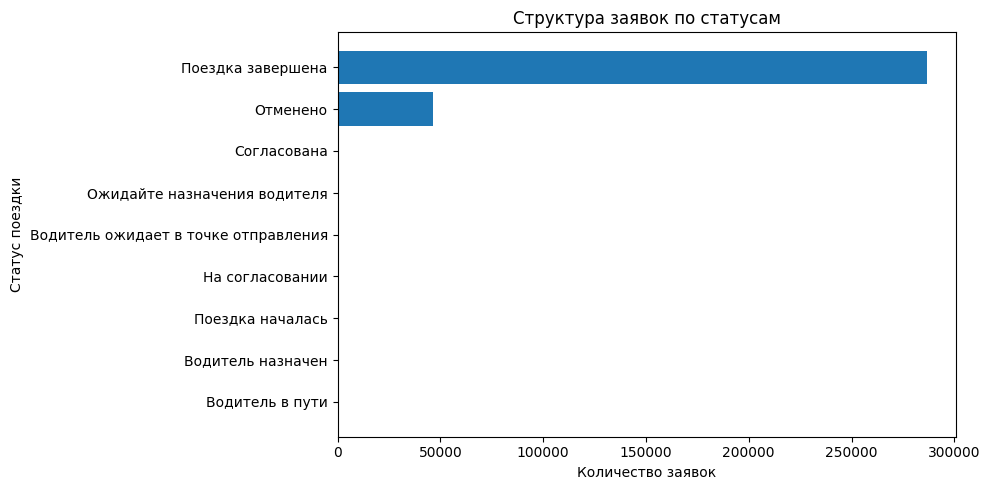

In [39]:
import matplotlib.pyplot as plt

status_plot = status_summary.sort_values(
    "Количество",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    status_plot["Статус поездки"],
    status_plot["Количество"]
)

plt.title("Структура заявок по статусам")
plt.xlabel("Количество заявок")
plt.ylabel("Статус поездки")

plt.tight_layout()
plt.show()

 3.2. Динамика заявок во времени

Для оценки изменения объёма заявок и результатов их исполнения рассмотрим динамику общего количества заявок, завершённых поездок и отмен.

В качестве периода используется дата создания заявки.

In [40]:
print(
    "Начало периода:",
    df_clean["Дата и время создания заявки"].min()
)

print(
    "Конец периода:",
    df_clean["Дата и время создания заявки"].max()
)

print(
    "Количество календарных дней:",
    df_clean["Дата и время создания заявки"]
    .dt.date
    .nunique()
)

Начало периода: 2025-06-01 00:02:34
Конец периода: 2025-12-31 23:26:55
Количество календарных дней: 214


Данные охватывают период с 1 июня по 31 декабря 2025 года — 214 календарных дней. Для оценки общей динамики заявки агрегируются по месяцам. При необходимости отдельные периоды с заметными изменениями будут дополнительно рассмотрены на более детальном уровне.

In [41]:
df_clean["Месяц создания"] = (
    df_clean["Дата и время создания заявки"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_dynamics = (
    df_clean
    .groupby("Месяц создания")
    .agg(
        Всего_заявок=("Номер заявки", "count"),
        Завершено=(
            "Статус поездки",
            lambda x: (x == "Поездка завершена").sum()
        ),
        Отменено=(
            "Статус поездки",
            lambda x: (x == "Отменено").sum()
        )
    )
    .reset_index()
)

monthly_dynamics["Доля завершённых, %"] = (
    monthly_dynamics["Завершено"]
    / monthly_dynamics["Всего_заявок"]
    * 100
).round(2)

monthly_dynamics["Доля отмен, %"] = (
    monthly_dynamics["Отменено"]
    / monthly_dynamics["Всего_заявок"]
    * 100
).round(2)

display(monthly_dynamics)

,Месяц создания,Всего_заявок,Завершено,Отменено,"Доля завершённых, %","Доля отмен, %"
0,2025-06-01,49187,41794,7131,84.97,14.50
1,2025-07-01,53448,44085,9228,82.48,17.27
2,2025-08-01,45546,38676,6691,84.92,14.69
3,2025-09-01,47511,40117,7089,84.44,14.92
4,2025-10-01,47157,40723,6280,86.36,13.32
5,2025-11-01,41056,36582,4381,89.10,10.67
6,2025-12-01,50613,44750,5738,88.42,11.34


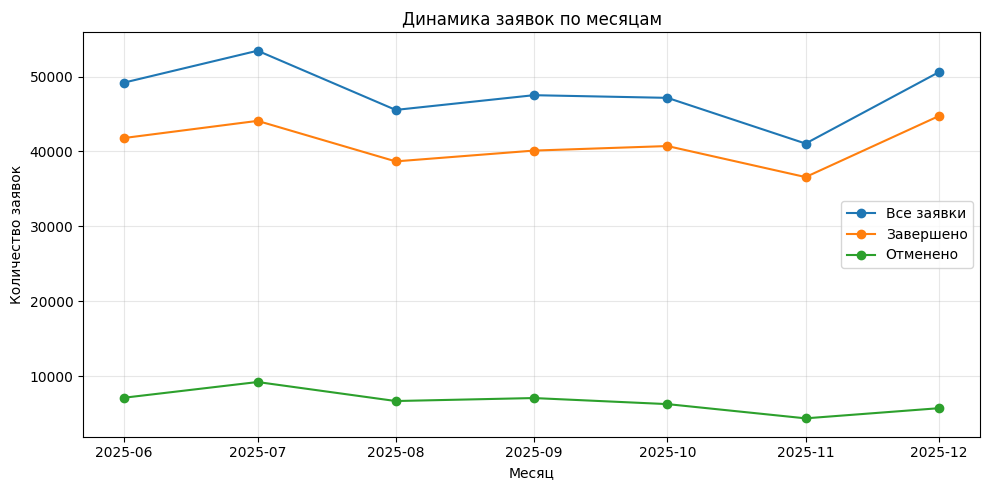

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_dynamics["Месяц создания"],
    monthly_dynamics["Всего_заявок"],
    marker="o",
    label="Все заявки"
)

plt.plot(
    monthly_dynamics["Месяц создания"],
    monthly_dynamics["Завершено"],
    marker="o",
    label="Завершено"
)

plt.plot(
    monthly_dynamics["Месяц создания"],
    monthly_dynamics["Отменено"],
    marker="o",
    label="Отменено"
)

plt.title("Динамика заявок по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заявок")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

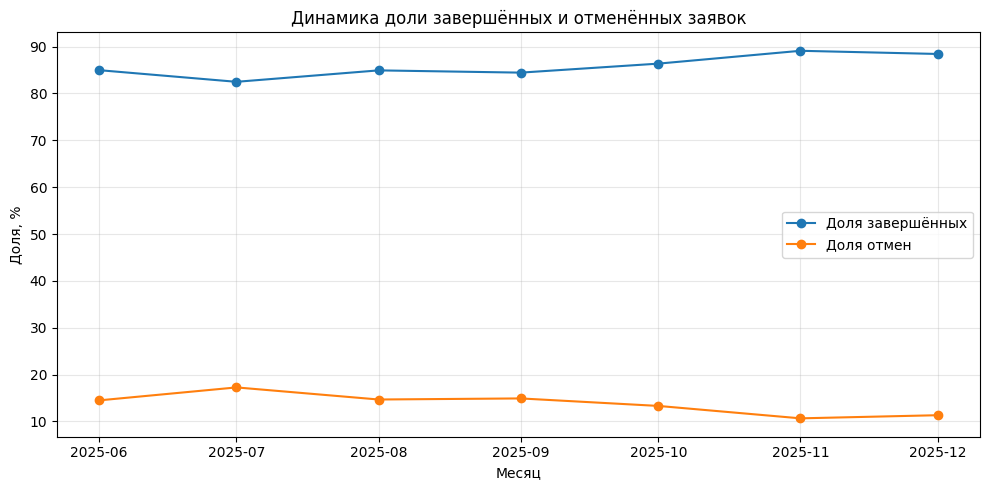

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_dynamics["Месяц создания"],
    monthly_dynamics["Доля завершённых, %"],
    marker="o",
    label="Доля завершённых"
)

plt.plot(
    monthly_dynamics["Месяц создания"],
    monthly_dynamics["Доля отмен, %"],
    marker="o",
    label="Доля отмен"
)

plt.title("Динамика доли завершённых и отменённых заявок")
plt.xlabel("Месяц")
plt.ylabel("Доля, %")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Динамика заявок по месяцам

Объём заявок в течение рассматриваемого периода изменялся неравномерно. Максимальное количество заявок зафиксировано в июле — 53 448, минимальное в ноябре — 41 056.

Июль также выделяется наиболее высокой долей отменённых заявок — 17,27% при доле завершённых 82,48%. Это худшее соотношение завершённых и отменённых заявок среди рассматриваемых месяцев.

Начиная с октября наблюдается снижение доли отмен: с 13,32% в октябре до минимальных 10,67% в ноябре. В ноябре одновременно зафиксирована максимальная доля завершённых заявок — 89,10%.

В декабре количество заявок увеличилось до 50 613 по сравнению с 41 056 в ноябре, при этом доля отмен составила 11,34%, оставаясь существенно ниже значений июня–сентября.

Таким образом, изменение количества отмен нельзя объяснить только изменением общего объёма заявок: доля отмен также заметно меняется во времени. Наиболее проблемным месяцем по этому показателю является июль, тогда как лучшие значения наблюдаются в ноябре и декабре. Причины различий требуют дальнейшего анализа структуры отмен и других характеристик поездок. 

Дополнительная проверка недельной динамики показала, что высокий уровень отмен в июле частично связан с резким всплеском на неделе, начавшейся 30 июня: доля отмен достигла 27,04%. На следующей неделе показатель также оставался повышенным и составил 16,82%.

Это указывает на локальный период повышенного количества отмен в начале июля. Для понимания возможных причин необходимо сопоставить данный период со структурой причин отмен.

In [44]:
df_clean["Неделя создания"] = (
    df_clean["Дата и время создания заявки"]
    .dt.to_period("W")
    .apply(lambda x: x.start_time)
)

weekly_dynamics = (
    df_clean
    .groupby("Неделя создания")
    .agg(
        Всего_заявок=("Номер заявки", "count"),
        Отменено=(
            "Статус поездки",
            lambda x: (x == "Отменено").sum()
        )
    )
    .reset_index()
)

weekly_dynamics["Доля отмен, %"] = (
    weekly_dynamics["Отменено"]
    / weekly_dynamics["Всего_заявок"]
    * 100
)

display(
    weekly_dynamics.sort_values(
        "Доля отмен, %",
        ascending=False
    ).head(10)
)

,Неделя создания,Всего_заявок,Отменено,"Доля отмен, %"
5,2025-06-30,13886,3755,27.041625
6,2025-07-07,11987,2016,16.818220
4,2025-06-23,12618,2106,16.690442
15,2025-09-08,11274,1828,16.214298
10,2025-08-04,11229,1798,16.012111
14,2025-09-01,11103,1680,15.131046
16,2025-09-15,10669,1612,15.109195
13,2025-08-25,10204,1536,15.052920
0,2025-05-26,703,102,14.509246
9,2025-07-28,11054,1600,14.474398


3.3. Причины отмен

In [45]:
cancelled = df_clean[
    df_clean["Статус поездки"] == "Отменено"
].copy()

cancel_reasons = (
    cancelled["Статус поездки (причина отмены)"]
    .fillna("Причина не указана")
    .value_counts()
    .rename_axis("Причина отмены")
    .reset_index(name="Количество")
)

cancel_reasons["Доля среди отмен, %"] = (
    cancel_reasons["Количество"]
    / len(cancelled)
    * 100
).round(2)

display(cancel_reasons)

,Причина отмены,Количество,"Доля среди отмен, %"
0,Отмена пользователем,27112,58.26
1,Не согласовано по истечению срока,9327,20.04
2,Отмена диспетчером,8023,17.24
3,Не согласовано,1569,3.37
4,Причина не указана,507,1.09


In [46]:
cancelled["Месяц создания"] = (
    cancelled["Дата и время создания заявки"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

cancelled["Причина отмены"] = (
    cancelled["Статус поездки (причина отмены)"]
    .fillna("Причина не указана")
)

cancel_reasons_monthly = pd.crosstab(
    cancelled["Месяц создания"],
    cancelled["Причина отмены"]
)

display(cancel_reasons_monthly)

Причина отмены,Не согласовано,Не согласовано по истечению срока,Отмена диспетчером,Отмена пользователем,Причина не указана
Месяц создания,,,,,
2025-06-01,172,1433,1925,3601,0
2025-07-01,410,1831,1862,5125,0
2025-08-01,198,1378,1145,3970,0
2025-09-01,284,1433,1151,4193,28
2025-10-01,200,1156,1123,3784,17
2025-11-01,139,895,560,2766,21
2025-12-01,166,1201,257,3673,441


In [47]:
cancel_reasons_monthly_pct = pd.crosstab(
    cancelled["Месяц создания"],
    cancelled["Причина отмены"],
    normalize="index"
) * 100

display(cancel_reasons_monthly_pct.round(2))

Причина отмены,Не согласовано,Не согласовано по истечению срока,Отмена диспетчером,Отмена пользователем,Причина не указана
Месяц создания,,,,,
2025-06-01,2.41,20.10,26.99,50.50,0.00
2025-07-01,4.44,19.84,20.18,55.54,0.00
2025-08-01,2.96,20.59,17.11,59.33,0.00
2025-09-01,4.01,20.21,16.24,59.15,0.39
2025-10-01,3.18,18.41,17.88,60.25,0.27
2025-11-01,3.17,20.43,12.78,63.14,0.48
2025-12-01,2.89,20.93,4.48,64.01,7.69



Основной причиной отмен является `Отмена пользователем` — 27 112 случаев, или 58,26% всех отменённых заявок.

На втором месте находится `Не согласовано по истечению срока` — 9 327 случаев (20,04%), далее следует `Отмена диспетчером` — 8 023 случаев (17,24%). На категорию `Не согласовано` приходится 3,37% отмен.

Для 507 отменённых заявок (1,09%) причина не указана.

Анализ причин отмен по месяцам не выявил одной отдельной категории, которая однозначно объясняла бы повышенную долю отмен в июле. В июле увеличилось абсолютное количество пользовательских отмен, однако структура причин в целом остаётся сопоставимой с соседними месяцами. Поэтому на основании имеющихся данных нельзя утверждать, что июльский всплеск был вызван одной конкретной причиной.

Отдельно выделяется декабрь: 441 из 507 заявок с отсутствующей причиной отмены приходится именно на этот месяц. В декабре такие записи составляют 7,69% всех отмен. Это может указывать на изменение качества заполнения данных или процесса регистрации причин отмен и требует дополнительной проверки источника данных.

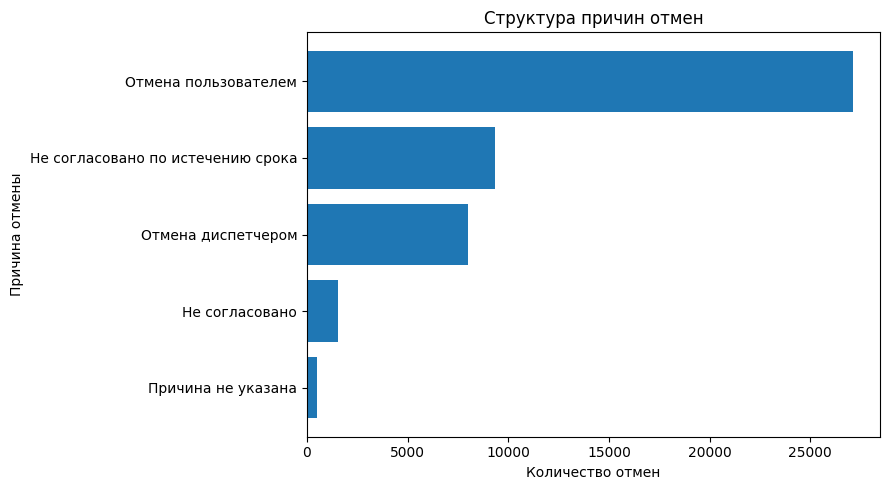

In [48]:
cancel_reasons_plot = cancel_reasons.sort_values(
    "Количество",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    cancel_reasons_plot["Причина отмены"],
    cancel_reasons_plot["Количество"]
)

plt.title("Структура причин отмен")
plt.xlabel("Количество отмен")
plt.ylabel("Причина отмены")

plt.tight_layout()
plt.show()

In [49]:
cost_by_status = (
    df_clean
    .groupby("Статус поездки")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Заявок_с_фактической_стоимостью=(
            "Фактическая стоимость в поездке, руб",
            "count"
        ),
        Сумма_фактической_стоимости=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

cost_by_status["Доля расходов, %"] = (
    cost_by_status["Сумма_фактической_стоимости"]
    / cost_by_status["Сумма_фактической_стоимости"].sum()
    * 100
)

cost_by_status = cost_by_status.sort_values(
    "Сумма_фактической_стоимости",
    ascending=False
)

display(cost_by_status)

,Статус поездки,Количество_заявок,Заявок_с_фактической_стоимостью,Сумма_фактической_стоимости,"Доля расходов, %"
6,Поездка завершена,286727,270177,8.942797e+08,96.718282
5,Отменено,46538,17764,2.974126e+07,3.216581
2,Водитель ожидает в точке отправления,315,279,5.240538e+05,0.056678
4,Ожидайте назначения водителя,330,36,6.037064e+04,0.006529
7,Поездка началась,19,13,1.589980e+04,0.001720
1,Водитель назначен,15,2,7.804500e+02,0.000084
0,Водитель в пути,6,2,7.212600e+02,0.000078
3,На согласовании,31,1,4.452800e+02,0.000048
8,Согласована,537,0,0.000000e+00,0.000000


In [50]:
print(
    "Фактическая стоимость по всем статусам:",
    f'{df_clean["Фактическая стоимость в поездке, руб"].sum():,.2f} руб.'
)

completed_cost = df_clean.loc[
    df_clean["Статус поездки"] == "Поездка завершена",
    "Фактическая стоимость в поездке, руб"
]

print(
    "Фактическая стоимость завершённых поездок:",
    f"{completed_cost.sum():,.2f} руб."
)

Фактическая стоимость по всем статусам: 924,623,276.56 руб.
Фактическая стоимость завершённых поездок: 894,279,746.35 руб.


## 4. Анализ расходов

Перед расчётом основных финансовых показателей была проверена структура фактической стоимости по статусам заявок.

Суммарная фактическая стоимость по всем заявкам, для которых показатель заполнен, составляет 924,62 млн руб. Основная часть — 894,28 млн руб. (96,72%) — приходится на завершённые поездки.

При этом 29,74 млн руб. (3,22% общей фактической стоимости) приходится на отменённые заявки. Следовательно, исключение всех отменённых заявок из общей оценки расходов привело бы к потере части зафиксированных затрат.

Поэтому далее используются два подхода:
- при анализе общего объёма и структуры зафиксированных расходов учитывается фактическая стоимость по всем статусам;
- при анализе стоимости выполненной поездки и сравнении плановых и фактических показателей основной выборкой являются завершённые поездки.

Наличие фактической стоимости у отменённых и отдельных незавершённых заявок также представляет самостоятельный интерес и будет учтено при анализе отмен и аномалий.

4.1. Средняя, медианная и экстремальная стоимость поездки

In [51]:
completed_trips = df_clean[
    (df_clean["Статус поездки"] == "Поездка завершена")
    & df_clean["Фактическая стоимость в поездке, руб"].notna()
].copy()

completed_cost = completed_trips[
    "Фактическая стоимость в поездке, руб"
]

print("Количество завершённых поездок с фактической стоимостью:",
      len(completed_trips))

print("Суммарная стоимость:",
      f"{completed_cost.sum():,.2f} руб.")

print("Средняя стоимость:",
      f"{completed_cost.mean():,.2f} руб.")

print("Медианная стоимость:",
      f"{completed_cost.median():,.2f} руб.")

print("Минимальная стоимость:",
      f"{completed_cost.min():,.2f} руб.")

print("Максимальная стоимость:",
      f"{completed_cost.max():,.2f} руб.")

Количество завершённых поездок с фактической стоимостью: 270177
Суммарная стоимость: 894,279,746.35 руб.
Средняя стоимость: 3,309.98 руб.
Медианная стоимость: 545.00 руб.
Минимальная стоимость: 0.00 руб.
Максимальная стоимость: 21,474,836.47 руб.


Квантили и нулвые стоимости:

In [52]:
cost_quantiles = completed_cost.quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(cost_quantiles)

zero_cost_completed = (
    completed_trips["Фактическая стоимость в поездке, руб"] == 0
).sum()

print("Завершённых поездок с нулевой стоимостью:",
      zero_cost_completed)

print(
    "Доля:",
    f"{zero_cost_completed / len(completed_trips) * 100:.2f}%"
)

0.01     200.000
0.05     298.490
0.25     387.230
0.50     545.000
0.75     855.900
0.95    2776.892
0.99    8795.240
Name: Фактическая стоимость в поездке, руб, dtype: float64

Завершённых поездок с нулевой стоимостью: 441
Доля: 0.16%


4.2. Стоимость завершённых поездок

Для анализа стоимости выполненных поездок рассмотрены 270 177 завершённых заявок с заполненной фактической стоимостью. Их суммарная стоимость составляет 894,28 млн руб.

Распределение стоимости имеет выраженную правостороннюю асимметрию. Медианная стоимость поездки составляет 545 руб., тогда как средняя — около 3 310 руб. Существенное превышение среднего над медианой связано с наличием относительно небольшого количества дорогостоящих поездок.

95% завершённых поездок имеют стоимость не выше 2 776,89 руб., а 99% — не выше 8 795,24 руб. При этом максимальная зафиксированная стоимость составляет около 21,47 млн руб., что многократно превышает основную часть наблюдений и требует отдельной проверки в разделе анализа аномалий.

Также обнаружена 441 завершённая поездка с нулевой фактической стоимостью (0,16% завершённых поездок с заполненным показателем). Эти наблюдения сохраняются для последующего анализа.

Таким образом, среднее значение стоимости существенно чувствительно к экстремальным наблюдениям. Для характеристики типичной поездки далее целесообразно использовать медиану совместно со средним значением и показателями распределения.

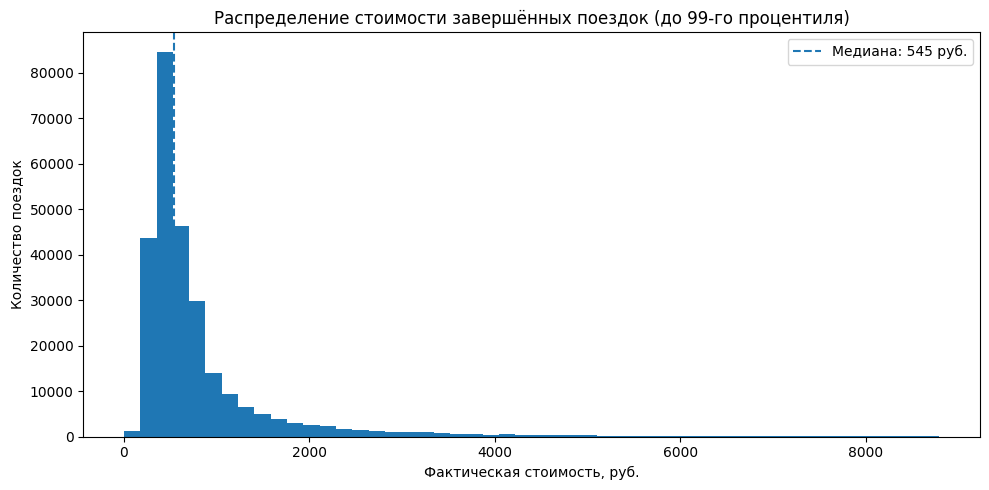

In [53]:
cost_p99 = completed_cost.quantile(0.99)

cost_for_plot = completed_cost[
    completed_cost <= cost_p99
]

plt.figure(figsize=(10, 5))

plt.hist(
    cost_for_plot,
    bins=50
)

plt.axvline(
    completed_cost.median(),
    linestyle="--",
    label=f"Медиана: {completed_cost.median():.0f} руб."
)

plt.title("Распределение стоимости завершённых поездок (до 99-го процентиля)")
plt.xlabel("Фактическая стоимость, руб.")
plt.ylabel("Количество поездок")
plt.legend()

plt.tight_layout()
plt.show()

4.3. Динамика расходов

In [54]:
monthly_cost = (
    df_clean
    .groupby("Месяц создания")
    .agg(
        Общие_расходы=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

completed_monthly_cost = (
    completed_trips
    .groupby("Месяц создания")
    .agg(
        Расходы_завершённых=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        ),
        Средняя_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "mean"
        ),
        Медианная_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "median"
        )
    )
    .reset_index()
)

monthly_cost = monthly_cost.merge(
    completed_monthly_cost,
    on="Месяц создания",
    how="left"
)

display(monthly_cost)

,Месяц создания,Общие_расходы,Расходы_завершённых,Средняя_стоимость,Медианная_стоимость
0,2025-06-01,6.854817e+08,6.622335e+08,16734.477241,542.420
1,2025-07-01,4.467636e+07,4.313464e+07,1035.645564,552.575
2,2025-08-01,3.980168e+07,3.871911e+07,1067.259651,540.730
3,2025-09-01,3.778032e+07,3.667271e+07,972.054645,546.000
4,2025-10-01,4.127074e+07,4.005511e+07,1048.096768,538.780
5,2025-11-01,3.404151e+07,3.317305e+07,963.940632,541.000
6,2025-12-01,4.157098e+07,4.029166e+07,952.138743,552.670


In [55]:
june_completed = completed_trips[
    completed_trips["Месяц создания"] == "2025-06-01"
].copy()

top_june_cost = (
    june_completed[
        [
            "Номер заявки",
            "Фактическая стоимость в поездке, руб",
            "Предварительная стоимость в заявке, руб",
            "Фактический километраж в поездке, км",
            "Предварительный километраж в заявке, км",
            "Цель поездки",
            "Вид тарифа",
            "ID подразделения",
            "Номер исполнителя"
        ]
    ]
    .sort_values(
        "Фактическая стоимость в поездке, руб",
        ascending=False
    )
    .head(20)
)

display(top_june_cost)

,Номер заявки,"Фактическая стоимость в поездке, руб","Предварительная стоимость в заявке, руб","Фактический километраж в поездке, км","Предварительный километраж в заявке, км",Цель поездки,Вид тарифа,ID подразделения,Номер исполнителя
329164,OT-0002-00757680,21474836.47,524,5.0,6.602,Доставка сотрудников в ночное время,Эконом,10346642,Исполнитель 53
329694,OT-0002-00765078,21474836.47,470,5.0,5.249,Доставка сотрудников в ночное время,Эконом,10334901,Исполнитель 53
329667,OT-0002-00766554,21474836.47,460,5.0,4.467,Доставка сотрудников в ночное время,Эконом,10320855,Исполнитель 53
329659,OT-0002-00766577,21474836.47,488,5.0,5.699,Доставка сотрудников в ночное время,Эконом,10339403,Исполнитель 53
329641,OT-0002-00767378,21474836.47,460,5.0,1.489,Доставка сотрудников в ночное время,Эконом,10334902,Исполнитель 53
329634,OT-0002-00767730,21474836.47,460,5.0,1.398,Доставка сотрудников в ночное время,Эконом,10360085,Исполнитель 53
329607,OT-0002-00768942,21474836.47,590,5.0,8.248,Доставка сотрудников в ночное время,Эконом,10360089,Исполнитель 53
280562,OT-0001-00161554,21474836.47,1218,5.0,12.808,Доставка сотрудников в ночное время,Комфорт,10293915,Исполнитель 53
280446,OT-0001-00161673,21474836.47,2886,5.0,36.980,Контроль СМР на объектах переформатирования,Эконом,10370365,Исполнитель 53
280323,OT-0001-00161730,21474836.47,899,5.0,9.013,Проведение служебных расследований,Комфорт,10373810,Исполнитель 53


In [56]:
thresholds = [10_000, 100_000, 1_000_000]

june_total_cost = june_completed[
    "Фактическая стоимость в поездке, руб"
].sum()

for threshold in thresholds:
    high_cost = june_completed[
        june_completed["Фактическая стоимость в поездке, руб"] > threshold
    ]

    high_cost_sum = high_cost[
        "Фактическая стоимость в поездке, руб"
    ].sum()

    print(f"Стоимость > {threshold:,.0f} руб.")
    print("Количество:", len(high_cost))
    print("Сумма:", f"{high_cost_sum:,.2f} руб.")
    print(
        "Доля расходов июня:",
        f"{high_cost_sum / june_total_cost * 100:.2f}%"
    )
    print()

Стоимость > 10,000 руб.
Количество: 346
Сумма: 628,163,405.22 руб.
Доля расходов июня: 94.86%

Стоимость > 100,000 руб.
Количество: 29
Сумма: 622,770,257.63 руб.
Доля расходов июня: 94.04%

Стоимость > 1,000,000 руб.
Количество: 29
Сумма: 622,770,257.63 руб.
Доля расходов июня: 94.04%



In [57]:
top_10_cost = (
    june_completed["Фактическая стоимость в поездке, руб"]
    .nlargest(10)
    .sum()
)

print(
    "Сумма 10 самых дорогих поездок:",
    f"{top_10_cost:,.2f} руб."
)

print(
    "Доля в расходах завершённых поездок июня:",
    f"{top_10_cost / june_total_cost * 100:.2f}%"
)

Сумма 10 самых дорогих поездок: 214,748,364.70 руб.
Доля в расходах завершённых поездок июня: 32.43%


#### Проверка экстремальных значений стоимости

Анализ месячных расходов выявил аномально высокий объём фактической стоимости в июне. Общие зафиксированные расходы за месяц составляют около 685,48 млн руб., тогда как в остальные месяцы рассматриваемого периода — примерно 34–45 млн руб.

При этом медианная стоимость завершённой июньской поездки составляет 542,42 руб. и практически не отличается от других месяцев, тогда как средняя стоимость возрастает до 16 734 руб. Это указывает на сильное влияние небольшого числа экстремально дорогих наблюдений.

Дополнительная проверка выявила группу из 30 заявок с одинаковой фактической стоимостью 21 474 836,47 руб. Все они относятся к июню и одному исполнителю — `Исполнитель 53`. Из них 29 заявок имеют статус `Поездка завершена`, одна — `Отменено`.

Для этих заявок характерно существенное расхождение между предварительной и фактической стоимостью. Кроме того, у всех 30 наблюдений фактический километраж равен 5 км, несмотря на различия в целях поездок, подразделениях и предварительных показателях.

Сочетание одинакового экстремального значения стоимости, одинакового фактического километража, концентрации у одного исполнителя и в одном месяце, а также существенного расхождения с предварительной стоимостью позволяет классифицировать эту группу как потенциальную техническую аномалию данных. Без информации об устройстве исходной системы точную причину возникновения значений установить невозможно.

Группа из 30 наблюдений формирует 644,25 млн руб., или 69,68% всей зафиксированной фактической стоимости за рассматриваемый период. После исключения влияния этой группы из аналитического расчёта общая сумма расходов снижается с 924,62 млн до 280,38 млн руб.

При этом исходные наблюдения из набора данных не удаляются. Для них создан отдельный признак аномалии, позволяющий анализировать финансовые показатели как в исходном виде, так и без влияния выявленной группы.

Кроме данной группы, в данных присутствуют ещё четыре завершённые поездки стоимостью более 1 млн руб., относящиеся к другому исполнителю и другим месяцам. Поскольку их значения стоимости различаются и не соответствуют описанному выше паттерну, они не классифицируются автоматически как та же техническая аномалия и требуют отдельной проверки.

In [58]:
# Флаг выявленной группы потенциально технических аномалий стоимости
df_clean["Аномалия стоимости 21.47 млн"] = (
    (df_clean["Фактическая стоимость в поездке, руб"] == 21_474_836.47)
    & (df_clean["Номер исполнителя"] == "Исполнитель 53")
    & (df_clean["Месяц создания"] == pd.Timestamp("2025-06-01"))
)

# Проверяем количество таких наблюдений
print("Количество выявленных аномальных записей:")
print(
    df_clean["Аномалия стоимости 21.47 млн"]
    .value_counts()
)

# Создаём отдельную выборку без этой группы.
# Исходный df_clean при этом не изменяем.
df_cost_adjusted = df_clean[
    ~df_clean["Аномалия стоимости 21.47 млн"]
].copy()

# Расходы по месяцам в исходных данных
monthly_cost_original = (
    df_clean
    .groupby("Месяц создания")
    .agg(
        Исходные_расходы=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

# Расходы по месяцам без выявленной группы аномалий
monthly_cost_adjusted = (
    df_cost_adjusted
    .groupby("Месяц создания")
    .agg(
        Расходы_без_аномалии=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

# Объединяем результаты для сравнения
monthly_cost_comparison = monthly_cost_original.merge(
    monthly_cost_adjusted,
    on="Месяц создания",
    how="left"
)

monthly_cost_comparison["Разница"] = (
    monthly_cost_comparison["Исходные_расходы"]
    - monthly_cost_comparison["Расходы_без_аномалии"]
)

display(monthly_cost_comparison)

# Сравниваем общие расходы
total_original = df_clean[
    "Фактическая стоимость в поездке, руб"
].sum()

total_adjusted = df_cost_adjusted[
    "Фактическая стоимость в поездке, руб"
].sum()

difference = total_original - total_adjusted
anomaly_share = difference / total_original * 100

print(
    "Исходные расходы:",
    f"{total_original:,.2f} руб."
)

print(
    "Расходы без группы из 29 аномальных записей:",
    f"{total_adjusted:,.2f} руб."
)

print(
    "Разница:",
    f"{difference:,.2f} руб."
)

print(
    "Доля аномальной группы в исходных расходах:",
    f"{anomaly_share:.2f}%"
)

Количество выявленных аномальных записей:
Аномалия стоимости 21.47 млн
False    334488
True         30
Name: count, dtype: int64


,Месяц создания,Исходные_расходы,Расходы_без_аномалии,Разница
0,2025-06-01,6.854817e+08,41236591.08,644245094.1
1,2025-07-01,4.467636e+07,44676362.80,0.0
2,2025-08-01,3.980168e+07,39801677.66,0.0
3,2025-09-01,3.778032e+07,37780320.11,0.0
4,2025-10-01,4.127074e+07,41270735.49,0.0
5,2025-11-01,3.404151e+07,34041511.67,0.0
6,2025-12-01,4.157098e+07,41570983.65,0.0


Исходные расходы: 924,623,276.56 руб.
Расходы без группы из 29 аномальных записей: 280,378,182.46 руб.
Разница: 644,245,094.10 руб.
Доля аномальной группы в исходных расходах: 69.68%


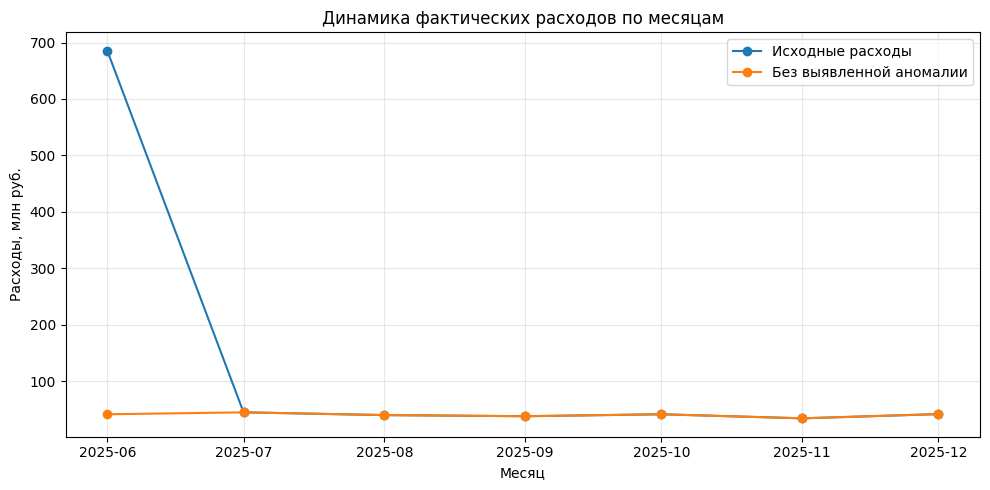

In [59]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_cost_comparison["Месяц создания"],
    monthly_cost_comparison["Исходные_расходы"] / 1_000_000,
    marker="o",
    label="Исходные расходы"
)

plt.plot(
    monthly_cost_comparison["Месяц создания"],
    monthly_cost_comparison["Расходы_без_аномалии"] / 1_000_000,
    marker="o",
    label="Без выявленной аномалии"
)

plt.title("Динамика фактических расходов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Расходы, млн руб.")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Динамика расходов

Исходная динамика расходов демонстрирует резкий пик в июне — около 685,48 млн руб. Однако 644,25 млн руб. этого значения связаны с выявленной группой из 30 потенциально технически аномальных записей.

Без влияния данной группы июньские расходы составляют около 41,24 млн руб. и становятся сопоставимыми с другими месяцами. Общая сумма зафиксированных расходов за рассматриваемый период при таком аналитическом сценарии снижается с 924,62 млн до 280,38 млн руб.

Таким образом, небольшое количество аномальных записей существенно искажает агрегированные финансовые показатели. При мониторинге расходов необходимо контролировать не только общую сумму затрат, но и экстремальные значения отдельных операций.

4.4. Структура расходов

Для анализа структуры расходов используется выборка без выявленной группы из 30 потенциально технически аномальных записей. Исходные данные при этом остаются неизменными.

Рассмотрим распределение зафиксированных расходов по целям поездок, тарифам и подразделениям.

In [60]:
# Расходы по целям поездки

cost_by_purpose = (
    df_cost_adjusted
    .groupby("Цель поездки")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Расходы=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

cost_by_purpose["Доля расходов, %"] = (
    cost_by_purpose["Расходы"]
    / cost_by_purpose["Расходы"].sum()
    * 100
)

cost_by_purpose = cost_by_purpose.sort_values(
    "Расходы",
    ascending=False
)

display(cost_by_purpose.head(10))

,Цель поездки,Количество_заявок,Расходы,"Доля расходов, %"
11,Доставка сотрудников в ночное время,178946,1.075337e+08,38.353079
0,Встречи с клиентами,77879,7.893322e+07,28.152411
18,Производственные (банковские) мероприятия,11646,2.105809e+07,7.510603
14,Проведение контрольных процедур,4008,1.276698e+07,4.553484
10,Доставка работников в ночное время,25060,1.109571e+07,3.957410
3,Выезды в государственные органы,8668,1.016975e+07,3.627154
9,Доставка подменного фонда работников в ВСП и о...,6329,8.471921e+06,3.021605
8,Доставка банковских карт,5841,5.994481e+06,2.137998
2,Встречи с контрагентами,5312,5.025355e+06,1.792349
15,Проведение наставничества ВСП,1246,4.872660e+06,1.737888


In [61]:
# Расходы по тарифам поездки

cost_by_tariff = (
    df_cost_adjusted
    .groupby("Вид тарифа")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Расходы=(
            "Фактическая стоимость в поездке, руб",
            "sum"
        )
    )
    .reset_index()
)

cost_by_tariff["Доля расходов, %"] = (
    cost_by_tariff["Расходы"]
    / cost_by_tariff["Расходы"].sum()
    * 100
)

cost_by_tariff = cost_by_tariff.sort_values(
    "Расходы",
    ascending=False
)

display(cost_by_tariff)

,Вид тарифа,Количество_заявок,Расходы,"Доля расходов, %"
8,Эконом,307188,2.380179e+08,84.891729
5,Комфорт,24168,3.632496e+07,12.955703
1,Автобус от 10 до 21 места,734,2.058614e+06,0.734228
0,Автобус до 9 мест,341,1.368303e+06,0.488020
2,Автобус от 22 до 41 места,538,1.178084e+06,0.420177
3,Автобус от 42 до 55 места,526,6.019239e+05,0.214683
6,Комфорт+,288,4.831630e+05,0.172325
4,Бизнес,100,3.452437e+05,0.123135
7,Служебный,605,0.000000e+00,0.000000


In [62]:
# Расходы по подразделениям

cost_by_department = (
    df_cost_adjusted
    .groupby("ID подразделения")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Расходы=("Фактическая стоимость в поездке, руб", "sum")
    )
    .reset_index()
)

cost_by_department["Доля расходов, %"] = (
    cost_by_department["Расходы"]
    / cost_by_department["Расходы"].sum()
    * 100
)

cost_by_department = cost_by_department.sort_values(
    "Расходы",
    ascending=False
)

display(cost_by_department.head(10))

,ID подразделения,Количество_заявок,Расходы,"Доля расходов, %"
4461,10366707,8948,6339024.04,2.260883
2440,10314853,3578,5366562.39,1.914044
3172,10345081,1646,4001938.71,1.427336
2585,10324394,2889,2873620.14,1.024909
4794,10367491,3650,2041118.07,0.727987
239,10132534,435,2003181.72,0.714457
4518,10366855,2735,2003078.07,0.714420
3115,10341928,256,1960749.85,0.699323
3108,10341781,338,1883588.65,0.671803
4859,10367675,2389,1839948.03,0.656238


In [63]:
# Расходы по исполнителям

cost_by_executor = (
    df_cost_adjusted
    .groupby("Номер исполнителя")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Расходы=("Фактическая стоимость в поездке, руб", "sum")
    )
    .reset_index()
    .sort_values("Расходы", ascending=False)
)

display(cost_by_executor.head(10))

,Номер исполнителя,Количество_заявок,Расходы
197,Нет данных,56122,41817589.56
126,Исполнитель 234,21680,30259038.44
186,Исполнитель 84,24676,23647980.84
110,Исполнитель 22,17252,12201220.09
58,Исполнитель 172,25438,12174702.53
164,Исполнитель 53,9202,10556433.07
169,Исполнитель 6,10180,10201660.00
9,Исполнитель 11,17230,9495910.37
28,Исполнитель 133,2634,8797876.91
22,Исполнитель 124,8195,7196096.25


In [64]:
# Расходы по маршрутам

df_cost_adjusted["Маршрут"] = (
    df_cost_adjusted["Адрес отправления"]
    + " → "
    + df_cost_adjusted["Адрес прибытия"]
)

cost_by_route = (
    df_cost_adjusted
    .groupby("Маршрут")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Расходы=("Фактическая стоимость в поездке, руб", "sum")
    )
    .reset_index()
    .sort_values("Расходы", ascending=False)
)

display(cost_by_route.head(10))

,Маршрут,Количество_заявок,Расходы
20795,"Москва, Кутузовский проспект, 32 к1 → Москва, ...",78,2197683.16
6470,"Воронежская область, Воронеж, 9 Января, 28 → В...",184,2110045.45
22518,"Москва, Кутузовский проспект, 32 к3 → Московск...",17,1846970.45
21100,"Москва, Кутузовский проспект, 32 к1 → Москва, ...",102,1236916.96
49945,"Приморский край, Владивосток, Фонтанная улица,...",828,1182720.09
58287,"Ростовская область, Ростов-на-Дону, улица Евдо...",388,1064538.38
24453,"Москва, Оружейный переулок, 41 → Москва, 1-й М...",1,1011278.00
7619,"Воронежская область, Воронеж, улица Ворошилова...",232,953880.81
68129,"Санкт-Петербург, Красного Текстильщика, 2 → Са...",461,860027.51
4294,"Волгоградская область, Урюпинск, проспект Лени...",134,854803.35


#### Структура расходов по целям поездок, тарифам, подразделениям, исполнителям и маршрутам

Наибольшая доля расходов приходится на поездки с целью `Доставка сотрудников в ночное время` — 38,35% общей суммы расходов без выделенной группы из 30 потенциально аномальных записей. На втором месте находятся `Встречи с клиентами` — 28,15%. Совместно эти две категории формируют около двух третей расходов.

При этом обе категории характеризуются большим количеством заявок, поэтому высокая доля расходов сама по себе не означает повышенную стоимость отдельной поездки. Для оценки типичной стоимости поездок дополнительно рассматриваются средние и медианные значения.

В структуре расходов по тарифам доминирует `Эконом`: на него приходится 84,89% расходов и подавляющее большинство заявок. Тариф `Комфорт` формирует ещё 12,96% расходов. Доля остальных тарифов значительно меньше.

Расходы по подразделениям распределены достаточно дробно. Крупнейшее по объёму расходов подразделение (ID 10366707) формирует 2,26% общей суммы, второе (ID 10314853) — 1,91%, третье (ID 10345081) — 1,43%. Таким образом, выраженной концентрации расходов на одном подразделении не наблюдается.

По исполнителям наибольшая сумма расходов приходится на записи со значением `Нет данных` — 41,82 млн руб. Это одновременно указывает на проблему качества данных: часть расходов невозможно однозначно отнести к конкретному исполнителю. Среди идентифицированных исполнителей наибольшие расходы приходятся на `Исполнитель 234` — 30,26 млн руб., `Исполнитель 84` — 23,65 млн руб. и `Исполнитель 22` — 12,20 млн руб. Высокая сумма расходов по исполнителю сама по себе не означает повышенную стоимость поездки, поскольку зависит в том числе от количества выполненных заявок.

Расходы по отдельным маршрутам значительно менее концентрированы. Наиболее затратный маршрут в выборке формирует около 2,20 млн руб. при 78 заявках, следующий — около 2,11 млн руб. при 184 заявках. При интерпретации этого среза необходимо учитывать, что маршрут сформирован как сочетание текстовых полей адреса отправления и прибытия. Различия в написании адресов могут разделять фактически похожие направления на отдельные категории.

Таким образом, основными драйверами общей суммы расходов являются прежде всего массовые цели поездок и наиболее распространённые тарифы. На уровне подразделений и отдельных маршрутов выраженной концентрации расходов не выявлено, а анализ по исполнителям дополнительно показывает необходимость контроля полноты заполнения данных об исполнителе.

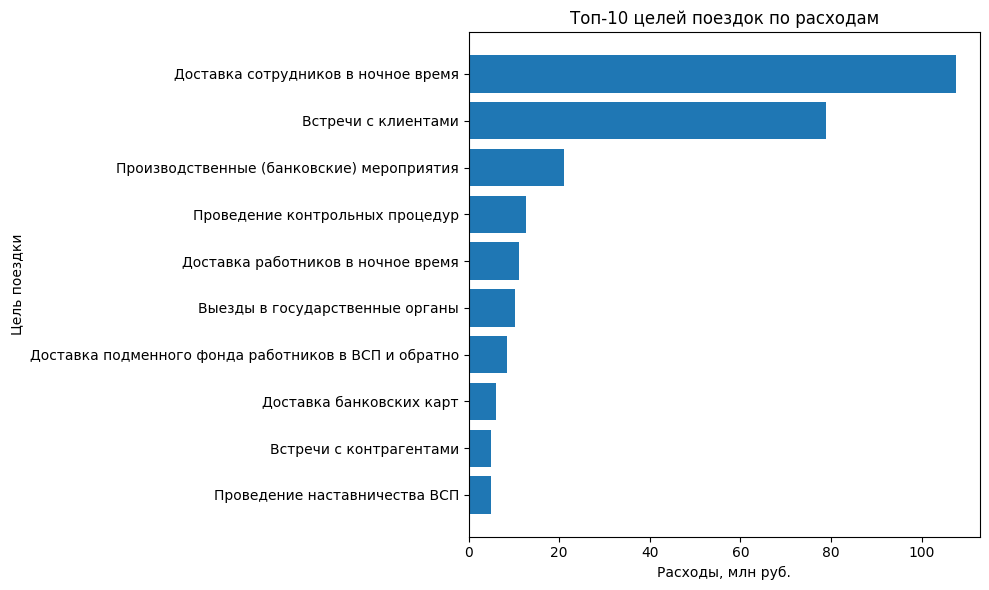

In [65]:
purpose_plot = (
    cost_by_purpose
    .head(10)
    .sort_values("Расходы")
)

plt.figure(figsize=(10, 6))

plt.barh(
    purpose_plot["Цель поездки"],
    purpose_plot["Расходы"] / 1_000_000
)

plt.title("Топ-10 целей поездок по расходам")
plt.xlabel("Расходы, млн руб.")
plt.ylabel("Цель поездки")

plt.tight_layout()
plt.show()

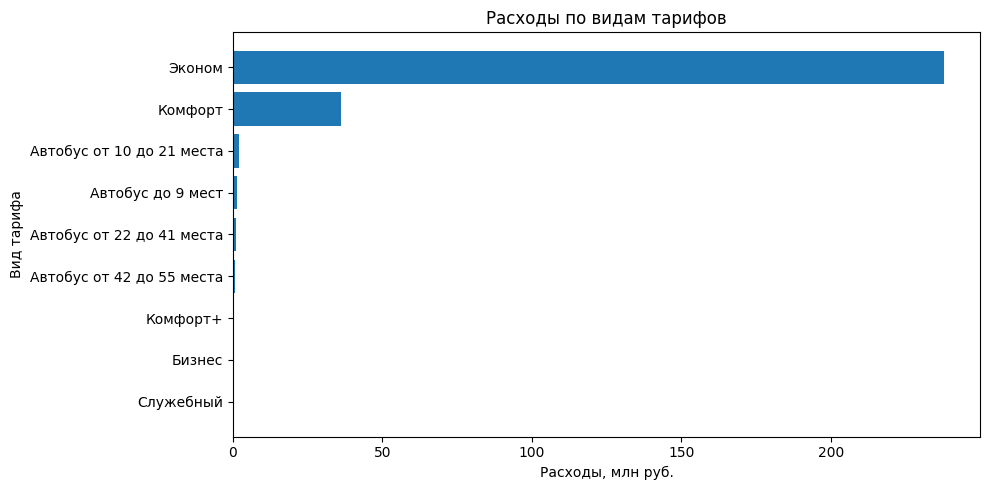

In [66]:
tariff_plot = cost_by_tariff.sort_values(
    "Расходы",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    tariff_plot["Вид тарифа"],
    tariff_plot["Расходы"] / 1_000_000
)

plt.title("Расходы по видам тарифов")
plt.xlabel("Расходы, млн руб.")
plt.ylabel("Вид тарифа")

plt.tight_layout()
plt.show()

In [67]:
# Стоимость одной поездки

completed_adjusted = df_clean[
    (df_clean["Статус поездки"] == "Поездка завершена")
    & df_clean["Фактическая стоимость в поездке, руб"].notna()
    & ~df_clean["Аномалия стоимости 21.47 млн"]
].copy()

# Стоимость по целям

cost_per_trip_by_purpose = (
    completed_adjusted
    .groupby("Цель поездки")
    .agg(
        Количество_поездок=("Номер заявки", "count"),
        Средняя_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "mean"
        ),
        Медианная_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "median"
        )
    )
    .reset_index()
)

cost_per_trip_by_purpose = cost_per_trip_by_purpose.sort_values(
    "Медианная_стоимость",
    ascending=False
)

display(cost_per_trip_by_purpose)

# Стоимость по тарифам

cost_per_trip_by_tariff = (
    completed_adjusted
    .groupby("Вид тарифа")
    .agg(
        Количество_поездок=("Номер заявки", "count"),
        Средняя_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "mean"
        ),
        Медианная_стоимость=(
            "Фактическая стоимость в поездке, руб",
            "median"
        )
    )
    .reset_index()
)

cost_per_trip_by_tariff = cost_per_trip_by_tariff.sort_values(
    "Медианная_стоимость",
    ascending=False
)

display(cost_per_trip_by_tariff)

,Цель поездки,Количество_поездок,Средняя_стоимость,Медианная_стоимость
15,Проведение наставничества ВСП,894,5284.826857,2442.375
16,Проведение проверки залогов,198,2617.443030,2190.045
14,Проведение контрольных процедур,2851,4371.627513,1834.640
6,Выезды на аварии,332,2819.250994,1597.530
12,Контроль СМР на объектах переформатирования,434,4255.313157,1414.420
5,Выезды к должникам Банка,769,3151.724889,1410.350
4,Выезды для участия в коллегиальных органах/раб...,1882,2351.392237,1311.325
13,Перемещение ВСП,178,1512.912528,1269.070
18,Производственные (банковские) мероприятия,7820,2621.618101,1124.545
7,Гемба,1414,1809.709463,1021.385


,Вид тарифа,Количество_поездок,Средняя_стоимость,Медианная_стоимость
2,Автобус от 22 до 41 места,46,25610.520435,16150.000
1,Автобус от 10 до 21 места,88,23366.376250,6666.640
0,Автобус до 9 мест,103,12504.797184,1984.540
4,Бизнес,46,7157.254565,1724.855
5,Комфорт,19290,1873.597793,1150.310
6,Комфорт+,218,2057.237523,1093.580
7,Эконом,250244,916.968370,521.190
3,Автобус от 42 до 55 места,113,5326.760531,1.000


#### Стоимость поездки по целям и тарифам

Сравнение средней и медианной стоимости показывает, что крупнейшие по общей сумме расходов категории не являются наиболее дорогими в расчёте на одну поездку.

Например, для категории `Доставка сотрудников в ночное время`, формирующей наибольшую долю общих расходов, медианная стоимость завершённой поездки составляет около 507 руб. Высокая доля этой категории в расходах связана прежде всего с большим количеством поездок.

Наиболее высокая медианная стоимость среди целей поездок наблюдается для `Проведение наставничества ВСП` — около 2 442 руб., `Проведение проверки залогов` — около 2 190 руб. и `Проведение контрольных процедур` — около 1 835 руб. При этом количество таких поездок существенно меньше, поэтому их вклад в общую сумму расходов ограничен.

Для большинства категорий средняя стоимость заметно превышает медианную, что свидетельствует о правосторонней асимметрии распределения и наличии отдельных дорогих поездок. Поэтому медиана используется как более устойчивая характеристика типичной стоимости.

По тарифам наиболее высокая типичная стоимость ожидаемо наблюдается у автобусных тарифов. Тариф `Эконом` является наиболее массовым и имеет медианную стоимость около 521 руб., тогда как для `Комфорт` медиана составляет около 1 150 руб.

При этом тариф `Автобус от 42 до 55 места` имеет медианную стоимость всего 1 руб., что выглядит нетипично для данной категории и требует отдельной проверки качества данных перед содержательной интерпретацией.

In [68]:
bus_42_55 = completed_adjusted[
    completed_adjusted["Вид тарифа"] == "Автобус от 42 до 55 места"
].copy()

print("Количество поездок:", len(bus_42_55))

print("\nРаспределение фактической стоимости:")
print(
    bus_42_55["Фактическая стоимость в поездке, руб"]
    .describe()
)

print("\nНаиболее частые значения стоимости:")
print(
    bus_42_55["Фактическая стоимость в поездке, руб"]
    .value_counts()
    .head(10)
)

print("\nКоличество поездок стоимостью 1 руб.:")
print(
    (bus_42_55["Фактическая стоимость в поездке, руб"] == 1).sum()
)

print("\nКоличество поездок стоимостью 0 руб.:")
print(
    (bus_42_55["Фактическая стоимость в поездке, руб"] == 0).sum()
)



display(
    bus_42_55[
        [
            "Предварительная стоимость в заявке, руб",
            "Фактическая стоимость в поездке, руб",
            "Предварительный километраж в заявке, км",
            "Фактический километраж в поездке, км",
            "Номер исполнителя"
        ]
    ]
    .sort_values("Фактическая стоимость в поездке, руб")
    .head(20)
)

Количество поездок: 113

Распределение фактической стоимости:
count      113.000000
mean      5326.760531
std      16028.571052
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      78525.000000
Name: Фактическая стоимость в поездке, руб, dtype: float64

Наиболее частые значения стоимости:
Фактическая стоимость в поездке, руб
1.00        94
42075.00     3
7.00         2
470.00       1
45125.00     1
2016.51      1
46455.00     1
78525.00     1
1986.43      1
58021.00     1
Name: count, dtype: int64

Количество поездок стоимостью 1 руб.:
94

Количество поездок стоимостью 0 руб.:
1


,"Предварительная стоимость в заявке, руб","Фактическая стоимость в поездке, руб","Предварительный километраж в заявке, км","Фактический километраж в поездке, км",Номер исполнителя
222245,20462,0.0,104.634,0.0,Исполнитель 85
232285,1,1.0,6.732,7.0,Нет данных
232279,1,1.0,6.732,7.0,Нет данных
232291,1,1.0,6.732,7.0,Нет данных
232296,1,1.0,6.732,7.0,Нет данных
234208,1,1.0,6.732,7.0,Нет данных
232581,1,1.0,55.360,56.0,Нет данных
232578,1,1.0,55.360,56.0,Нет данных
232574,1,1.0,55.360,56.0,Нет данных
232569,1,1.0,55.360,56.0,Нет данных


#### Особенность стоимости тарифа «Автобус от 42 до 55 места»

Дополнительная проверка показала, что низкая медианная стоимость тарифа `Автобус от 42 до 55 места` обусловлена систематическим присутствием значения 1 руб.: оно встречается в 94 из 113 завершённых поездок с заполненной фактической стоимостью (83,2%).

Для многих таких поездок предварительная стоимость также составляет 1 руб., при этом показатели километража содержат ненулевые значения. Следовательно, наблюдаемая стоимость не является результатом единичного выброса и может отражать специальную бизнес-логику тарификации либо особенность формирования данных.

Без дополнительного описания тарифной модели однозначно классифицировать значение 1 руб. как ошибку нельзя. Поэтому такие наблюдения сохраняются в анализе, однако финансовые показатели данного тарифа следует интерпретировать с осторожностью.

4.5. План/факт стоимости

In [69]:
# Завершённые поездки, где известны и плановая, и фактическая стоимость
cost_plan_fact = completed_adjusted[
    completed_adjusted["Предварительная стоимость в заявке, руб"].notna()
    & completed_adjusted["Фактическая стоимость в поездке, руб"].notna()
].copy()

cost_plan_fact["Отклонение стоимости, руб"] = (
    cost_plan_fact["Фактическая стоимость в поездке, руб"]
    - cost_plan_fact["Предварительная стоимость в заявке, руб"]
)

cost_plan_fact["Отклонение стоимости, %"] = (
    cost_plan_fact["Отклонение стоимости, руб"]
    / cost_plan_fact["Предварительная стоимость в заявке, руб"]
    * 100
)

print("Количество поездок:", len(cost_plan_fact))

print("\nПлановая стоимость:")
print(
    cost_plan_fact["Предварительная стоимость в заявке, руб"]
    .describe()
)

print("\nФактическая стоимость:")
print(
    cost_plan_fact["Фактическая стоимость в поездке, руб"]
    .describe()
)

print("\nОтклонение стоимости, руб.:")
print(
    cost_plan_fact["Отклонение стоимости, руб"]
    .describe()
)

print("\nОтклонение стоимости, %:")
print(
    cost_plan_fact["Отклонение стоимости, %"]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

Количество поездок: 270148

Плановая стоимость:
count    270148.000000
mean        927.368713
std        1795.951633
min           1.000000
25%         388.000000
50%         534.000000
75%         822.000000
max      188892.000000
Name: Предварительная стоимость в заявке, руб, dtype: float64

Фактическая стоимость:
count    2.701480e+05
mean     1.005040e+03
std      6.596306e+03
min      0.000000e+00
25%      3.872000e+02
50%      5.449200e+02
75%      8.552650e+02
max      2.163150e+06
Name: Фактическая стоимость в поездке, руб, dtype: float64

Отклонение стоимости, руб.:
count    2.701480e+05
mean     7.767108e+01
std      6.347233e+03
min     -5.634700e+04
25%     -3.465000e+01
50%      4.600000e+00
75%      7.141250e+01
max      2.162577e+06
Name: Отклонение стоимости, руб, dtype: float64

Отклонение стоимости, %:
count    270148.000000
mean         10.363924
std         926.347479
min        -100.000000
1%          -58.281794
5%          -34.782609
25%          -4.781742
50%    

In [70]:
# Направления отклонений

higher_cost = (
    cost_plan_fact["Фактическая стоимость в поездке, руб"]
    > cost_plan_fact["Предварительная стоимость в заявке, руб"]
).sum()

lower_cost = (
    cost_plan_fact["Фактическая стоимость в поездке, руб"]
    < cost_plan_fact["Предварительная стоимость в заявке, руб"]
).sum()

same_cost = (
    cost_plan_fact["Фактическая стоимость в поездке, руб"]
    == cost_plan_fact["Предварительная стоимость в заявке, руб"]
).sum()

total = len(cost_plan_fact)

print(
    "Факт выше плана:",
    higher_cost,
    f"({higher_cost / total * 100:.2f}%)"
)

print(
    "Факт ниже плана:",
    lower_cost,
    f"({lower_cost / total * 100:.2f}%)"
)

print(
    "Факт равен плану:",
    same_cost,
    f"({same_cost / total * 100:.2f}%)"
)

Факт выше плана: 151198 (55.97%)
Факт ниже плана: 106035 (39.25%)
Факт равен плану: 12915 (4.78%)


4.6. План/факт километража

In [71]:
km_plan_fact = completed_adjusted[
    completed_adjusted["Предварительный километраж в заявке, км"].notna()
    & completed_adjusted["Фактический километраж в поездке, км"].notna()
].copy()

km_plan_fact["Отклонение километража, км"] = (
    km_plan_fact["Фактический километраж в поездке, км"]
    - km_plan_fact["Предварительный километраж в заявке, км"]
)

# Процентное отклонение считаем только при положительном плановом километраже
km_plan_fact["Отклонение километража, %"] = np.nan

positive_plan_km = (
    km_plan_fact["Предварительный километраж в заявке, км"] > 0
)

km_plan_fact.loc[
    positive_plan_km,
    "Отклонение километража, %"
] = (
    km_plan_fact.loc[
        positive_plan_km,
        "Отклонение километража, км"
    ]
    / km_plan_fact.loc[
        positive_plan_km,
        "Предварительный километраж в заявке, км"
    ]
    * 100
)

print("Количество поездок:", len(km_plan_fact))

print("\nОтклонение километража, км:")
print(
    km_plan_fact["Отклонение километража, км"]
    .describe()
)

print("\nОтклонение километража, %:")
print(
    km_plan_fact["Отклонение километража, %"]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

Количество поездок: 270148

Отклонение километража, км:
count    270148.000000
mean          1.368010
std          91.166224
min       -1063.742000
25%          -0.175000
50%           0.178000
75%           1.023000
max       30282.137000
Name: Отклонение километража, км, dtype: float64

Отклонение километража, %:
count    270146.000000
mean         14.145919
std        1551.590290
min        -100.000000
1%          -87.254327
5%          -32.637700
25%          -1.912702
50%           1.981676
75%          11.338518
95%          48.148148
99%         179.581530
max      783902.070929
Name: Отклонение километража, %, dtype: float64


In [72]:
cost_deviation_summary = cost_plan_fact[
    ["Отклонение стоимости, руб", "Отклонение стоимости, %"]
].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(cost_deviation_summary.round(2))

print(
    "Среднее отклонение стоимости, руб:",
    round(cost_plan_fact["Отклонение стоимости, руб"].mean(), 2)
)

print(
    "Медианное отклонение стоимости, руб:",
    round(cost_plan_fact["Отклонение стоимости, руб"].median(), 2)
)

print(
    "Максимальное отклонение стоимости, руб:",
    round(cost_plan_fact["Отклонение стоимости, руб"].max(), 2)
)

print(
    "Минимальное отклонение стоимости, руб:",
    round(cost_plan_fact["Отклонение стоимости, руб"].min(), 2)
)

,"Отклонение стоимости, руб","Отклонение стоимости, %"
0.01,-917.56,-58.28
0.05,-313.00,-34.78
0.25,-34.65,-4.78
0.50,4.60,0.82
0.75,71.41,12.67
0.95,438.00,49.68
0.99,2076.77,159.80


Среднее отклонение стоимости, руб: 77.67
Медианное отклонение стоимости, руб: 4.6
Максимальное отклонение стоимости, руб: 2162576.76
Минимальное отклонение стоимости, руб: -56347.0


In [73]:
cost_plan_fact["Абсолютное отклонение стоимости, %"] = (
    cost_plan_fact["Отклонение стоимости, %"].abs()
)

km_plan_fact["Абсолютное отклонение километража, %"] = (
    km_plan_fact["Отклонение километража, %"].abs()
)

cost_threshold = cost_plan_fact[
    "Абсолютное отклонение стоимости, %"
].quantile(0.99)

km_threshold = km_plan_fact[
    "Абсолютное отклонение километража, %"
].quantile(0.99)

print(
    "Порог верхнего 1% абсолютных отклонений стоимости:",
    round(cost_threshold, 2),
    "%"
)

print(
    "Порог верхнего 1% абсолютных отклонений километража:",
    round(km_threshold, 2),
    "%"
)

Порог верхнего 1% абсолютных отклонений стоимости: 159.8 %
Порог верхнего 1% абсолютных отклонений километража: 179.58 %


4.7. План/факт времени поездки

In [74]:
time_plan_fact = df_clean[
    (df_clean["Статус поездки"] == "Поездка завершена")
    & df_clean["Фактическое время поездки, мин"].notna()
].copy()

print("Завершённых поездок с фактическим временем:", len(time_plan_fact))

print(
    "Завершённых поездок без фактического времени:",
    (
        (df_clean["Статус поездки"] == "Поездка завершена")
        & df_clean["Фактическое время поездки, мин"].isna()
    ).sum()
)

print(
    "Нулевое фактическое время:",
    (time_plan_fact["Фактическое время поездки, мин"] == 0).sum()
)

time_plan_fact_valid = time_plan_fact[
    (time_plan_fact["Предварительное время в заявке, час/мин"] > 0)
    & (time_plan_fact["Фактическое время поездки, мин"] > 0)
].copy()

time_plan_fact_valid["Отклонение времени, мин"] = (
    time_plan_fact_valid["Фактическое время поездки, мин"]
    - time_plan_fact_valid["Предварительное время в заявке, час/мин"]
)

time_plan_fact_valid["Отклонение времени, %"] = (
    time_plan_fact_valid["Отклонение времени, мин"]
    / time_plan_fact_valid["Предварительное время в заявке, час/мин"]
    * 100
)

display(
    time_plan_fact_valid[
        ["Отклонение времени, мин", "Отклонение времени, %"]
    ].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ).T
)

Завершённых поездок с фактическим временем: 152982
Завершённых поездок без фактического времени: 133745
Нулевое фактическое время: 65429


,count,mean,std,min,5%,25%,50%,75%,95%,max
"Отклонение времени, мин",87546.0,28.885923,69.711426,-859.000000,-10.000000,0.0,1.000000,9.000000,174.000000,1340.0
"Отклонение времени, %",87546.0,148.139109,399.094985,-99.591837,-33.333333,0.0,2.857143,44.117647,958.823529,17900.0


### Сравнение плановых и фактических показателей

#### Стоимость

Для 270 148 завершённых поездок доступны одновременно плановая и фактическая стоимость.

Фактическая стоимость превышает предварительную в 55,97% поездок, оказывается ниже неё в 39,25% и полностью совпадает в 4,78% случаев.

При этом типичное расхождение невелико: медианное отклонение составляет +4,60 руб., или +0,82% относительно предварительной стоимости. У половины поездок относительное отклонение находится примерно в диапазоне от -4,78% до +12,67%.

Среднее отклонение составляет +77,67 руб. и заметно превышает медианное. Это связано с наличием правого хвоста распределения: для 5% поездок превышение плана составляет более 49,68%, а для 1% — более 159,80%. Максимальные отклонения значительно выше и требуют отдельного анализа как потенциальные аномалии.

Таким образом, на уровне типичной поездки предварительная оценка стоимости достаточно близка к фактической, однако небольшая доля поездок характеризуется существенными расхождениями и способна заметно влиять на агрегированные показатели.

#### Километраж

Для 270 148 завершённых поездок также доступны плановый и фактический километраж.

Медианное абсолютное отклонение фактического километража от предварительного составляет +0,178 км, а медианное относительное отклонение — около +1,98%. Для половины наблюдений относительное отклонение находится примерно между -1,91% и +11,34%.

Одновременно распределение содержит выраженные экстремальные значения: на уровне 99-го процентиля отклонение достигает +179,58%, а максимальные значения существенно выше. Поэтому среднее относительное отклонение (+14,15%) менее устойчиво и не должно использоваться отдельно для характеристики типичной поездки.

#### Время поездки

Фактическое время поездки заполнено для 152 982 из 286 727 завершённых поездок. При этом в 65 429 записях фактическая длительность равна нулю. Для сравнения планового и фактического времени использованы 87 546 завершённых поездок с положительными значениями обоих показателей.

Медианное отклонение фактического времени от предварительного составляет +1 минуту, или около +2,86%. Для половины анализируемых поездок отклонение находится в диапазоне от 0 до +9 минут, или от 0% до +44,12%.

Распределение имеет выраженный правый хвост: для 5% анализируемых поездок превышение предварительного времени составляет более 174 минут, а относительное отклонение — более 958,82%. Среднее отклонение (+28,89 минуты) поэтому значительно выше медианного и хуже характеризует типичную поездку.

Высокая доля пропущенных и нулевых значений фактического времени ограничивает интерпретацию данного показателя. Полученные результаты характеризуют только поездки с корректно заполненной положительной длительностью и не должны автоматически распространяться на все завершённые поездки.

#### Итог по план/факт

Для типичной поездки предварительные оценки стоимости и километража достаточно близки к фактическим значениям: медианное относительное отклонение составляет +0,82% для стоимости и +1,98% для километража.

Для времени поездки медианное отклонение также относительно невелико (+2,86%), однако качество заполнения этого показателя существенно ниже, а распределение содержит более выраженные отклонения.

Для последующего поиска сильных расхождений стоимости и километража в качестве статистического ориентира используется верхний 1% абсолютных относительных отклонений: 159,80% для стоимости и 179,58% для километража. Эти пороги используются только для выделения наблюдений для дополнительной проверки и не являются нормативными бизнес-границами.

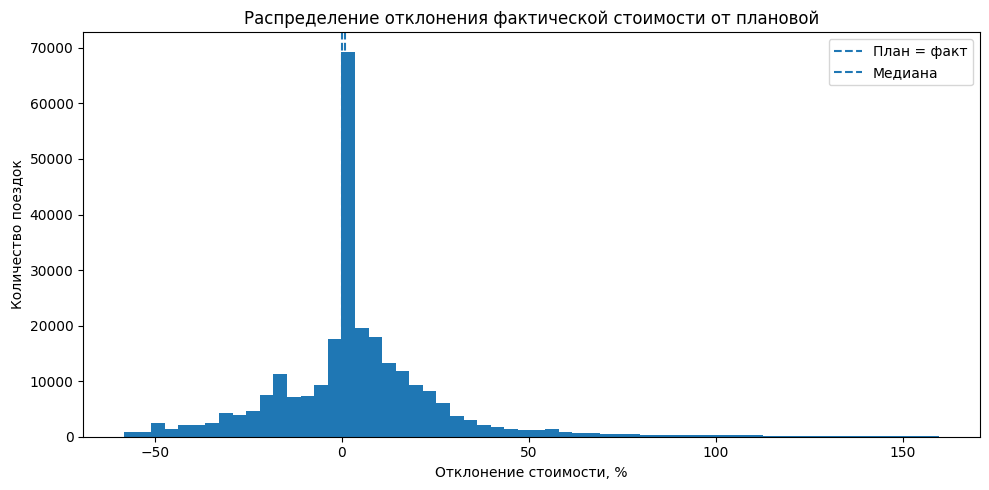

In [75]:
# Для визуализации ограничиваем диапазон 1-м и 99-м процентилями.
# Исходные наблюдения при этом не удаляются.
lower = cost_plan_fact["Отклонение стоимости, %"].quantile(0.01)
upper = cost_plan_fact["Отклонение стоимости, %"].quantile(0.99)

cost_deviation_plot = cost_plan_fact[
    cost_plan_fact["Отклонение стоимости, %"].between(lower, upper)
]

plt.figure(figsize=(10, 5))

plt.hist(
    cost_deviation_plot["Отклонение стоимости, %"],
    bins=60
)

plt.axvline(
    0,
    linestyle="--",
    label="План = факт"
)

plt.axvline(
    cost_plan_fact["Отклонение стоимости, %"].median(),
    linestyle="--",
    label="Медиана"
)

plt.title("Распределение отклонения фактической стоимости от плановой")
plt.xlabel("Отклонение стоимости, %")
plt.ylabel("Количество поездок")
plt.legend()

plt.tight_layout()
plt.show()

Для читаемости графика показан диапазон между 1-м и 99-м процентилями относительного отклонения стоимости. Экстремальные наблюдения не удаляются из данных и рассматриваются отдельно при анализе аномалий.

In [76]:
sla_data = df_clean[
    df_clean["SLA подачи ТС соблюдён"].notna()
].copy()

sla_by_month = (
    sla_data
    .groupby("Месяц создания")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Нарушения_SLA=(
            "SLA подачи ТС соблюдён",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

sla_by_month["SLA соблюдено, %"] = (
    (sla_by_month["Количество_заявок"] - sla_by_month["Нарушения_SLA"])
    / sla_by_month["Количество_заявок"]
    * 100
)

sla_by_month["Доля нарушений, %"] = (
    sla_by_month["Нарушения_SLA"]
    / sla_by_month["Количество_заявок"]
    * 100
)

display(sla_by_month)

,Месяц создания,Количество_заявок,Нарушения_SLA,"SLA соблюдено, %","Доля нарушений, %"
0,2025-06-01,42379,516,98.782416,1.217584
1,2025-07-01,44601,379,99.150243,0.849757
2,2025-08-01,39090,394,98.992070,1.007930
3,2025-09-01,40449,365,99.097629,0.902371
4,2025-10-01,41189,273,99.337202,0.662798
5,2025-11-01,36641,184,99.497830,0.502170
6,2025-12-01,44881,348,99.224616,0.775384


In [77]:
sla_by_executor = (
    sla_data
    .groupby("Номер исполнителя")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Нарушения_SLA=(
            "SLA подачи ТС соблюдён",
            lambda x: (~x).sum()
        ),
        Медианное_отклонение_прибытия=(
            "Отклонение прибытия от контрольного срока, мин",
            "median"
        )
    )
    .reset_index()
)

sla_by_executor["Доля нарушений, %"] = (
    sla_by_executor["Нарушения_SLA"]
    / sla_by_executor["Количество_заявок"]
    * 100
)

sla_by_executor_filtered = (
    sla_by_executor[
        sla_by_executor["Количество_заявок"] >= 100
    ]
    .sort_values(
        "Доля нарушений, %",
        ascending=False
    )
)

display(sla_by_executor_filtered.head(15))

,Номер исполнителя,Количество_заявок,Нарушения_SLA,Медианное_отклонение_прибытия,"Доля нарушений, %"
87,Исполнитель 236,507,162,-110.450000,31.952663
50,Исполнитель 183,598,94,-15.750000,15.719064
101,Исполнитель 32,1206,161,-27.383333,13.349917
126,Исполнитель 6,8247,447,-31.466667,5.420153
114,Исполнитель 46,264,12,-24.575000,4.545455
116,Исполнитель 48,1347,50,-24.233333,3.711952
43,Исполнитель 174,225,6,-39.200000,2.666667
121,Исполнитель 53,7361,168,-26.416667,2.282299
95,Исполнитель 27,4169,93,-22.483333,2.230751
67,Исполнитель 21,495,8,-32.533333,1.616162


### 5. Анализ времени подачи ТС и соблюдения SLA

Для оценки своевременности подачи ТС используется технический критерий: заявка считается выполненной в срок, если фактическое время прибытия ТС не превышает расчётный контрольный срок подачи.

Из анализа исключаются наблюдения, для которых невозможно корректно рассчитать показатель, в том числе записи с отсутствующим временем прибытия или контрольным сроком и выявленные ранее случаи прибытия ТС раньше времени создания заявки.

В результате для оценки SLA доступны 289 230 заявок. Контрольный срок соблюдён в 286 771 случае, нарушения выявлены в 2 459 случаях. Общая доля соблюдения SLA составляет 99,15%.

#### Динамика SLA

На протяжении рассматриваемого периода доля соблюдения SLA остаётся высокой и находится в диапазоне от 98,78% до 99,50%.

Наибольшая доля нарушений наблюдается в июне — 1,22%, далее показатель в целом снижается и достигает минимума в ноябре — 0,50%. В декабре доля нарушений увеличивается до 0,78%, но остаётся ниже июньского уровня.

Таким образом, выраженного системного ухудшения SLA во времени не наблюдается.

#### SLA по исполнителям

На уровне отдельных исполнителей различия существенно выше, чем на уровне месяцев. Среди исполнителей минимум со 100 валидными заявками наиболее высокая доля нарушений наблюдается у `Исполнитель 236` — 31,95%, `Исполнитель 183` — 15,72% и `Исполнитель 32` — 13,35%.

Для сравнения, общий уровень нарушений составляет около 0,85%. Поэтому данные исполнители являются потенциальными зонами внимания и требуют дополнительного анализа причин отклонений.

При этом медианное отклонение времени прибытия у этих исполнителей остаётся отрицательным, то есть более половины соответствующих заявок выполняются раньше контрольного срока. Это показывает, что агрегированная медиана не отражает стабильность исполнения: одновременно могут присутствовать как ранние прибытия, так и значительная доля опозданий.

Порог в 100 валидных заявок используется как аналитическое ограничение для исключения исполнителей с малым числом наблюдений и не является нормативным бизнес-критерием.

In [78]:
# Подразделения и маршруты

sla_by_department = (
    sla_data
    .groupby("ID подразделения")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Нарушения_SLA=(
            "SLA подачи ТС соблюдён",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

sla_by_department["Доля нарушений, %"] = (
    sla_by_department["Нарушения_SLA"]
    / sla_by_department["Количество_заявок"]
    * 100
)

sla_by_department_filtered = (
    sla_by_department[
        sla_by_department["Количество_заявок"] >= 100
    ]
    .sort_values("Доля нарушений, %", ascending=False)
)

display(sla_by_department_filtered.head(15))

,ID подразделения,Количество_заявок,Нарушения_SLA,"Доля нарушений, %"
775,10228185,302,99,32.781457
4345,10367426,546,117,21.428571
3756,10365209,176,28,15.909091
1114,10254806,684,78,11.403509
2345,10324394,2523,247,9.789933
2734,10339452,101,9,8.910891
1488,10285949,131,10,7.633588
3338,10359777,136,8,5.882353
2729,10339403,496,28,5.645161
4745,10372359,117,6,5.128205


In [79]:
# По сложности маршрута

sla_by_route_points = (
    sla_data
    .groupby("Количество точек в маршруте")
    .agg(
        Количество_заявок=("Номер заявки", "count"),
        Нарушения_SLA=(
            "SLA подачи ТС соблюдён",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

sla_by_route_points["Доля нарушений, %"] = (
    sla_by_route_points["Нарушения_SLA"]
    / sla_by_route_points["Количество_заявок"]
    * 100
)

sla_by_route_points = sla_by_route_points.sort_values(
    "Количество точек в маршруте"
)

display(sla_by_route_points)

,Количество точек в маршруте,Количество_заявок,Нарушения_SLA,"Доля нарушений, %"
0,2,245232,1983,0.808622
1,3,23697,290,1.223784
2,4,10056,80,0.795545
3,5,9297,77,0.828224
4,6,341,9,2.639296
5,7,190,3,1.578947
6,8,91,5,5.494505
7,9,61,2,3.278689
8,10,94,3,3.191489
9,11,24,2,8.333333


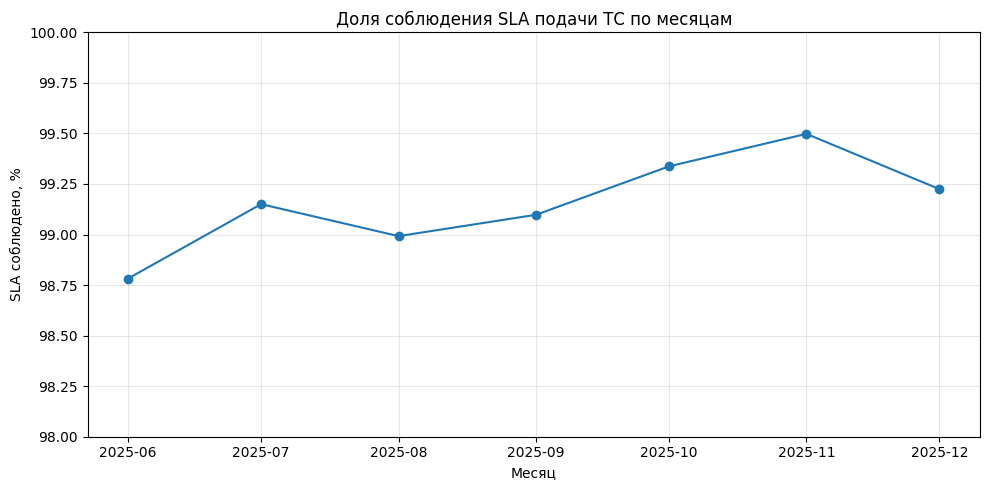

In [80]:
plt.figure(figsize=(10, 5))

plt.plot(
    sla_by_month["Месяц создания"],
    sla_by_month["SLA соблюдено, %"],
    marker="o"
)

plt.title("Доля соблюдения SLA подачи ТС по месяцам")
plt.xlabel("Месяц")
plt.ylabel("SLA соблюдено, %")

plt.ylim(98, 100)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### SLA по подразделениям и сложности маршрута

На уровне подразделений выявлены отдельные зоны с существенно повышенной долей нарушений SLA. Среди подразделений минимум со 100 валидными заявками наибольшая доля нарушений наблюдается у подразделений `10228185` — 32,78%, `10367426` — 21,43% и `10365209` — 15,91%.

Эти значения значительно превышают общий уровень нарушений около 0,85%, поэтому данные подразделения требуют дополнительной проверки. При этом высокая доля нарушений сама по себе не позволяет определить причину: она может быть связана с географией поездок, исполнителями, временем заказа, особенностями маршрутов или другими факторами.

По сложности маршрута основная масса заявок приходится на маршруты из 2–5 точек. Для них доля нарушений SLA составляет от 0,80% до 1,22%.

Для маршрутов с большим количеством точек наблюдаются отдельные высокие значения доли нарушений, однако количество таких заявок невелико. Например, показатели 33–50% для отдельных категорий основаны всего на 2–3 наблюдениях. Поэтому делать вывод о систематическом ухудшении SLA с ростом количества точек маршрута на основании этих значений нельзя.

In [81]:
shared_cols = [
    "Инициатор совместной поездки",
    "Количество присоединенных заявок",
    "ID Совместной поездки",
    "Финансовый эффект для организации (присоединённые заявки), руб",
    "Финансовый эффект для организации (забронированные места), руб",
    "Итоговый финансовый эффект для организации, руб",
    "Экономия бюджета для подразделения, руб"
]

for col in shared_cols:
    print(f"\n--- {col} ---")
    print("Заполнено:", df_clean[col].notna().sum())
    print("Уникальных значений:", df_clean[col].nunique())


print("Инициатор совместной поездки:")
print(
    df_clean["Инициатор совместной поездки"]
    .value_counts(dropna=False)
)

print("\nКоличество присоединенных заявок:")
print(
    df_clean["Количество присоединенных заявок"]
    .value_counts(dropna=False)
    .sort_index()
)


financial_effect_cols = [
    "Финансовый эффект для организации (присоединённые заявки), руб",
    "Финансовый эффект для организации (забронированные места), руб",
    "Итоговый финансовый эффект для организации, руб",
    "Экономия бюджета для подразделения, руб"
]

display(
    df_clean[financial_effect_cols]
    .describe()
    .T
)


--- Инициатор совместной поездки ---
Заполнено: 334518
Уникальных значений: 2

--- Количество присоединенных заявок ---
Заполнено: 334518
Уникальных значений: 2

--- ID Совместной поездки ---
Заполнено: 89017
Уникальных значений: 89004

--- Финансовый эффект для организации (присоединённые заявки), руб ---
Заполнено: 76667
Уникальных значений: 8

--- Финансовый эффект для организации (забронированные места), руб ---
Заполнено: 288274
Уникальных значений: 15714

--- Итоговый финансовый эффект для организации, руб ---
Заполнено: 288274
Уникальных значений: 15715

--- Экономия бюджета для подразделения, руб ---
Заполнено: 288274
Уникальных значений: 8
Инициатор совместной поездки:
Инициатор совместной поездки
Нет    245514
Да      89004
Name: count, dtype: int64

Количество присоединенных заявок:
Количество присоединенных заявок
0    334508
1        10
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
"Финансовый эффект для организации (присоединённые заявки), руб",76667.0,0.037461,3.896739,0.00,0.0,0.0,0.0,603.84
"Финансовый эффект для организации (забронированные места), руб",288274.0,525.045934,29464.618642,-0.02,0.0,0.0,0.0,11086409.94
"Итоговый финансовый эффект для организации, руб",288274.0,525.055897,29464.618533,-0.02,0.0,0.0,0.0,11086409.94
"Экономия бюджета для подразделения, руб",288274.0,0.009963,1.421004,0.00,0.0,0.0,0.0,301.92


### 6. Совместные поездки и финансовый эффект

В наборе данных присутствуют признаки, связанные с совместными поездками и их финансовым эффектом. `ID Совместной поездки` заполнен для 89 017 записей, однако поле `Количество присоединенных заявок` практически всегда равно нулю: значение 1 встречается только в 10 случаях.

Финансовые показатели также требуют осторожной интерпретации. Для большинства наблюдений значения финансового эффекта равны нулю, при этом встречаются отдельные экстремально высокие значения. Кроме того, два отдельных поля экономии совместных поездок полностью не заполнены и были исключены на этапе подготовки данных.

Без описания бизнес-логики формирования `ID Совместной поездки`, признака инициатора и показателей финансового эффекта однозначно определить механизм объединения заявок и корректно оценить совокупную экономию невозможно.

Поэтому количественная оценка экономического эффекта совместных поездок в рамках данного анализа не выполняется. Для её проведения требуется дополнительный словарь данных и описание правил расчёта соответствующих показателей.

## 7. Анализ аномалий

Поиск аномалий проводился не только по экстремальным числовым значениям, но и по логической согласованности показателей. В качестве потенциальных аномалий рассматриваются:

- экстремально высокая или низкая стоимость;
- сильные расхождения плановой и фактической стоимости;
- сильные расхождения планового и фактического километража;
- необычные значения времени ожидания;
- логически противоречивые временные последовательности;
- локальная концентрация необычных значений у отдельных исполнителей или категорий.

Выявленные наблюдения не удаляются автоматически. В зависимости от характера они классифицируются как потенциальная ошибка данных, особенность бизнес-процесса либо объект для дополнительной проверки.

7.1. Четыре оставшиеся поездки дороже 1 млн

In [82]:
other_expensive_trips = completed_adjusted[
    completed_adjusted["Фактическая стоимость в поездке, руб"] > 1_000_000
].copy()

display(
    other_expensive_trips[
        [
            "Номер заявки",
            "Месяц создания",
            "Предварительная стоимость в заявке, руб",
            "Фактическая стоимость в поездке, руб",
            "Предварительный километраж в заявке, км",
            "Фактический километраж в поездке, км",
            "Цель поездки",
            "Вид тарифа",
            "Номер исполнителя"
        ]
    ]
)

,Номер заявки,Месяц создания,"Предварительная стоимость в заявке, руб","Фактическая стоимость в поездке, руб","Предварительный километраж в заявке, км","Фактический километраж в поездке, км",Цель поездки,Вид тарифа,Номер исполнителя
297270,OT-0001-00174881,2025-08-01,2093,1012360.01,22.731,14173.1,Доставка сотрудников в ночное время,Комфорт,Исполнитель 234
297364,OT-0001-00174638,2025-08-01,573,2163149.76,3.863,30286.0,Доставка сотрудников в ночное время,Комфорт,Исполнитель 234
311031,OT-0002-00889251,2025-10-01,2605,1812066.91,32.576,28281.3,Доставка сотрудников в ночное время,Эконом,Исполнитель 234
311332,OT-0013-00197985,2025-10-01,1120,1011278.00,11.376,14157.9,Встречи с клиентами,Комфорт,Исполнитель 234


7.2. Экстремальное время ожидания

In [83]:
waiting = df_clean["Суммарное фактическое время ожидания, мин."]

print("Отрицательное время ожидания:")
print((waiting < 0).sum())

print("\nВремя ожидания больше 24 часов:")
print((waiting > 24 * 60).sum())

print("\nВремя ожидания больше 7 суток:")
print((waiting > 7 * 24 * 60).sum())

print("\nНаиболее экстремальные значения:")
print(
    waiting
    .dropna()
    .sort_values()
    .head(5)
)

print(
    waiting
    .dropna()
    .sort_values(ascending=False)
    .head(5)
)

Отрицательное время ожидания:
4

Время ожидания больше 24 часов:
23

Время ожидания больше 7 суток:
22

Наиболее экстремальные значения:
49242    -8921001.0
96900    -8913832.0
139399   -8838012.0
224189   -8742075.0
27              0.0
Name: Суммарное фактическое время ожидания, мин., dtype: float64
232824    18000000.0
242270    10800000.0
271686     9600000.0
205337     9000000.0
205280     9000000.0
Name: Суммарное фактическое время ожидания, мин., dtype: float64


### Результаты анализа аномалий

В ходе анализа выявлено несколько различных типов потенциальных аномалий.

**1. Экстремальные значения фактической стоимости.**

Отдельную группу образуют 30 июньских заявок с одинаковой фактической стоимостью 21 474 836,47 руб. Все записи относятся к `Исполнитель 53`, имеют фактический километраж 5 км и существенно более низкую предварительную стоимость. Данная группа формирует 644,25 млн руб., или 69,68% всей зафиксированной фактической стоимости в исходных данных.

Сочетание одинаковой экстремальной стоимости, концентрации у одного исполнителя и в одном периоде, одинакового километража и значительного расхождения с предварительной стоимостью позволяет рассматривать эти наблюдения как потенциальную техническую аномалию. Для анализа расходов их влияние рассматривается отдельно, при этом исходные записи не удаляются.

**2. Другие поездки с экстремально высокой стоимостью.**

После исключения указанной группы остаются ещё четыре завершённые поездки стоимостью более 1 млн руб. Все они относятся к `Исполнитель 234`.

Для этих поездок одновременно наблюдается экстремально высокий фактический километраж — от 14,2 до 30,3 тыс. км — при предварительном километраже примерно от 4 до 33 км. Предварительная стоимость при этом находится в диапазоне от 573 до 2 605 руб., тогда как фактическая превышает 1 млн руб.

Одновременное экстремальное увеличение стоимости и километража позволяет классифицировать эти записи как потенциальные ошибки данных либо случаи, требующие обязательной проверки в первичной системе. Точная причина отклонений без дополнительной информации не устанавливается.

**3. Сильные расхождения плановых и фактических показателей.**

Для основной массы завершённых поездок расхождения плановых и фактических значений относительно невелики. Однако распределения стоимости и километража имеют выраженные хвосты.

В качестве статистического ориентира для выделения сильных отклонений использован верхний 1% абсолютных относительных расхождений. Порог составляет около 159,8% для стоимости и 179,6% для километража. Данные значения не являются бизнес-нормативами и используются только как аналитический критерий отбора наблюдений для дополнительной проверки.

**4. Аномальные значения времени ожидания.**

В поле суммарного фактического времени ожидания обнаружены 4 отрицательных значения. Также выявлены 23 наблюдения с ожиданием более 24 часов, из которых 22 превышают 7 суток.

Экстремальные значения достигают миллионов минут: минимальное значение составляет -8 921 001 мин., максимальное — 18 000 000 мин. Такие значения не интерпретируются как содержательное время ожидания и рассматриваются как потенциальные ошибки формирования или хранения данных.

**5. Логические противоречия временных признаков.**

Выявлено 4 273 случая, когда фактическое прибытие ТС указано раньше времени создания заявки, а также 144 случая, когда время завершения заявки предшествует фактическому времени прибытия ТС.

Такие наблюдения нарушают ожидаемую последовательность событий и рассматриваются как проблемы качества временных данных. Записи с некорректной временной последовательностью не использовались при расчёте показателя соблюдения контрольного срока подачи ТС.

**6. Нетипичные, но не подтверждённые как ошибочные значения.**

Для тарифа `Автобус от 42 до 55 места` в 94 из 113 завершённых поездок с заполненной стоимостью фактическая стоимость составляет 1 руб. Во многих случаях предварительная стоимость также равна 1 руб., при этом километраж заполнен содержательными ненулевыми значениями.

В отличие от явных экстремальных значений, без знания тарифной модели такие записи нельзя однозначно признать ошибочными. Они рассматриваются как особенность данных, требующая уточнения бизнес-логики.

## Основные выводы


1. **За рассматриваемый период зарегистрировано 334 518 заявок.** Из них 85,71% завершены, 13,91% отменены, остальные 0,37% находятся в других статусах процесса. Наиболее высокая доля отмен наблюдалась в июле — 17,27%, основная причина отмен — отмена пользователем (58,26% отменённых заявок).

2. **Исходные финансовые показатели существенно искажены небольшой группой потенциально технических аномалий.** 30 заявок с одинаковой стоимостью 21,47 млн руб. формируют 644,25 млн руб., или 69,68% всей зафиксированной фактической стоимости. Без влияния этой группы расходы за период составляют около 280,38 млн руб. вместо 924,62 млн руб.

3. **Основные драйверы расходов связаны прежде всего с объёмом поездок.** На `Доставку сотрудников в ночное время` приходится 38,35% расходов, на `Встречи с клиентами` — 28,15%. В структуре тарифов доминирует `Эконом`, формирующий 84,89% расходов без выделенной группы потенциально аномальных записей. Расходы по подразделениям и отдельным маршрутам распределены более дробно.

4. **На уровне типичной завершённой поездки плановые стоимость и километраж достаточно близки к фактическим значениям.** Медианное отклонение стоимости составляет +4,60 руб., или +0,82%, а километража — +0,178 км, или около +1,98%. При этом присутствует небольшой сегмент поездок с существенными расхождениями plan/fact.

5. **Сравнение plan/fact времени ограничено качеством заполнения данных.** Для 87 546 завершённых поездок с положительными значениями медианное отклонение составляет +1 минуту, или +2,86%. Однако у 133 745 завершённых поездок фактическое время отсутствует, а ещё у 65 429 указано нулевое значение, поэтому результат нельзя распространять на все завершённые поездки.

6. **Общий показатель соблюдения расчётного контрольного срока подачи ТС высокий — 99,15%, однако агрегированный результат скрывает локальные проблемные зоны.** Среди исполнителей минимум со 100 валидными заявками доля нарушений достигает 31,95% у `Исполнитель 236`, 15,72% у `Исполнитель 183` и 13,35% у `Исполнитель 32`. Аналогичные локальные отклонения выявлены среди подразделений.

7. **В данных выявлены проблемы качества, способные существенно влиять на бизнес-метрики.** Помимо аномальной стоимости обнаружены экстремальные значения километража и времени ожидания, нарушения временной последовательности, большое количество отсутствующих и нулевых значений фактической длительности поездки, а также неполное заполнение данных об исполнителе.

8. **Количественная оценка финансового эффекта совместных поездок по имеющимся данным ограничена.** Без словаря данных и правил формирования соответствующих показателей корректно оценить совокупную экономию невозможно.


## Рекомендации

### Операционные рекомендации

- Провести отдельный анализ причин повышенной доли нарушений контрольного срока у исполнителей и подразделений, существенно отклоняющихся от общего уровня.

- Детализировать причины июльского роста отмен и отслеживать динамику пользовательских отмен и несогласованных заявок.

- Для наиболее массовых целей поездок (`Доставка сотрудников в ночное время`, `Встречи с клиентами`) искать возможности оптимизации прежде всего за счёт объёма и организации поездок, поскольку именно они формируют основную часть расходов.

- Дополнительно анализировать поездки с сильным превышением плановой стоимости, километража и времени для выявления повторяющихся причин отклонений.


### Рекомендации по качеству данных

- Внедрить автоматические проверки экстремальных значений стоимости и километража перед включением данных в финансовую отчётность.

- Контролировать логическую последовательность временных событий: создание заявки → желаемое отправление → прибытие ТС → завершение поездки.

- Добавить проверки отрицательных и физически маловероятных значений времени ожидания.

- Контролировать заполнение фактической длительности поездки и отдельно определить бизнес-смысл нулевых значений этого показателя.

- Повысить полноту заполнения данных об исполнителе, поскольку существенная часть расходов сейчас относится к значению `Нет данных`.

- Уточнить бизнес-логику стоимости 1 руб. для отдельных автобусных тарифов и при необходимости выделить технические значения отдельным признаком.

- Формализовать правила заполнения признаков совместных поездок и методику расчёта финансового эффекта.

- Подготовить словарь данных с описанием идентификаторов, статусов, финансовых показателей и правил формирования расчётных полей.


## KPI для регулярного мониторинга

Для регулярного контроля процесса рекомендуется отслеживать:

- количество созданных и завершённых заявок;
- долю завершённых и отменённых заявок;
- структуру причин отмен;
- общую сумму фактических расходов;
- медианную стоимость завершённой поездки;
- расходы по целям поездок, тарифам, подразделениям, исполнителям и маршрутам;
- медианное и 95-й процентиль отклонения фактической стоимости от плановой;
- медианное и 95-й процентиль отклонения фактического километража от планового;
- медианное и 95-й процентиль отклонения фактического времени поездки от планового;
- долю соблюдения расчётного контрольного срока подачи ТС;
- долю нарушений контрольного срока по исполнителям и подразделениям;
- количество заявок с аномальными значениями стоимости, километража и времени;
- количество записей с нарушенной временной последовательностью;
- долю пропущенных и нулевых значений в ключевых операционных и финансовых полях.

## Подготовка данных для BI-дашборда

Для построения BI-дашборда используется аналитический датасет, сформированный на основе очищенных и проверенных данных данного ноутбука.

В итоговую BI-витрину добавлены расчётные признаки для анализа расходов, отклонений план/факт, соблюдения контрольного срока подачи ТС и выявленных аномалий. Итоговый файл `taxi_clean.csv` используется как источник данных для Power BI.

In [84]:
# Создаём отдельную аналитическую витрину для Power BI
df_bi = df_clean.copy()


# --------------------------------------------------
# 1. Фактическая стоимость без выделенной группы
#    из 30 потенциально технических аномалий
# --------------------------------------------------

df_bi["Фактическая стоимость без аномалии, руб"] = (
    df_bi["Фактическая стоимость в поездке, руб"]
    .where(~df_bi["Аномалия стоимости 21.47 млн"])
)


# --------------------------------------------------
# 2. План / факт стоимости
# --------------------------------------------------

df_bi["Отклонение стоимости, руб"] = (
    df_bi["Фактическая стоимость в поездке, руб"]
    - df_bi["Предварительная стоимость в заявке, руб"]
)

df_bi["Отклонение стоимости, %"] = np.nan

positive_plan_cost = (
    df_bi["Предварительная стоимость в заявке, руб"] > 0
)

df_bi.loc[
    positive_plan_cost,
    "Отклонение стоимости, %"
] = (
    df_bi.loc[
        positive_plan_cost,
        "Отклонение стоимости, руб"
    ]
    / df_bi.loc[
        positive_plan_cost,
        "Предварительная стоимость в заявке, руб"
    ]
    * 100
)


# --------------------------------------------------
# 3. План / факт километража
# --------------------------------------------------

df_bi["Отклонение километража, км"] = (
    df_bi["Фактический километраж в поездке, км"]
    - df_bi["Предварительный километраж в заявке, км"]
)

df_bi["Отклонение километража, %"] = np.nan

positive_plan_km = (
    df_bi["Предварительный километраж в заявке, км"] > 0
)

df_bi.loc[
    positive_plan_km,
    "Отклонение километража, %"
] = (
    df_bi.loc[
        positive_plan_km,
        "Отклонение километража, км"
    ]
    / df_bi.loc[
        positive_plan_km,
        "Предварительный километраж в заявке, км"
    ]
    * 100
)


# --------------------------------------------------
# 4. План / факт времени поездки
# --------------------------------------------------

df_bi["Отклонение времени, мин"] = np.nan
df_bi["Отклонение времени, %"] = np.nan

valid_time = (
    (df_bi["Статус поездки"] == "Поездка завершена")
    & (df_bi["Предварительное время в заявке, час/мин"] > 0)
    & (df_bi["Фактическое время поездки, мин"] > 0)
)

df_bi.loc[
    valid_time,
    "Отклонение времени, мин"
] = (
    df_bi.loc[
        valid_time,
        "Фактическое время поездки, мин"
    ]
    - df_bi.loc[
        valid_time,
        "Предварительное время в заявке, час/мин"
    ]
)

df_bi.loc[
    valid_time,
    "Отклонение времени, %"
] = (
    df_bi.loc[
        valid_time,
        "Отклонение времени, мин"
    ]
    / df_bi.loc[
        valid_time,
        "Предварительное время в заявке, час/мин"
    ]
    * 100
)


# --------------------------------------------------
# 5. Маршрут
# --------------------------------------------------

df_bi["Маршрут"] = (
    df_bi["Адрес отправления"].fillna("Нет данных")
    + " → "
    + df_bi["Адрес прибытия"].fillna("Нет данных")
)


# --------------------------------------------------
# 6. Удобные флаги для Power BI
# --------------------------------------------------

df_bi["Завершена"] = (
    df_bi["Статус поездки"] == "Поездка завершена"
)

df_bi["Отменена"] = (
    df_bi["Статус поездки"] == "Отменено"
)

df_bi["Нарушение контрольного срока"] = (
    df_bi["SLA подачи ТС соблюдён"] == False
)


# --------------------------------------------------
# 7. Флаги сильных отклонений plan / fact
#    по порогам, использованным в анализе
# --------------------------------------------------

df_bi["Сильное отклонение стоимости"] = (
    df_bi["Отклонение стоимости, %"].abs() > 159.80
)

df_bi["Сильное отклонение километража"] = (
    df_bi["Отклонение километража, %"].abs() > 179.58
)


# --------------------------------------------------
# 8. Общий признак записей, требующих внимания
# --------------------------------------------------

df_bi["Требует внимания"] = (
    df_bi["Аномалия стоимости 21.47 млн"].fillna(False)
    | df_bi["Сильное отклонение стоимости"].fillna(False)
    | df_bi["Сильное отклонение километража"].fillna(False)
    | df_bi["Нарушение контрольного срока"].fillna(False)
)


# --------------------------------------------------
# 9. Экспорт BI-витрины
# --------------------------------------------------

df_bi.to_csv(
    "taxi_clean.csv",
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 10. Контроль после экспорта
# --------------------------------------------------

print("Файл taxi_clean.csv подготовлен для Power BI")
print("Количество строк:", len(df_bi))
print("Количество столбцов:", df_bi.shape[1])

print(
    "Количество выявленных аномалий стоимости 21.47 млн:",
    df_bi["Аномалия стоимости 21.47 млн"].sum()
)

print(
    "Расходы без выделенной группы аномалий:",
    f'{df_bi["Фактическая стоимость без аномалии, руб"].sum():,.2f} руб.'
)

print(
    "Количество нарушений контрольного срока:",
    df_bi["Нарушение контрольного срока"].sum()
)

print(
    "Количество записей, требующих внимания:",
    df_bi["Требует внимания"].sum()
)

Файл taxi_clean.csv подготовлен для Power BI
Количество строк: 334518
Количество столбцов: 68
Количество выявленных аномалий стоимости 21.47 млн: 30
Расходы без выделенной группы аномалий: 280,378,182.46 руб.
Количество нарушений контрольного срока: 2459
Количество записей, требующих внимания: 6531


In [85]:
# Облегчённая витрина для Power BI
# Оставляем только поля, которые используются в дашборде

bi_columns = [
    # Идентификация и период
    "Номер заявки",
    "Дата и время создания заявки",
    "Месяц создания",

    # Статус поездки
    "Статус поездки",
    "Статус поездки (причина отмены)",
    "Завершена",
    "Отменена",

    # Основные аналитические срезы
    "Вид тарифа",
    "Цель поездки",
    "ID подразделения",
    "Номер исполнителя",
    "Маршрут",
    "Количество точек в маршруте",

    # Стоимость
    "Предварительная стоимость в заявке, руб",
    "Фактическая стоимость в поездке, руб",
    "Фактическая стоимость без аномалии, руб",
    "Отклонение стоимости, руб",
    "Отклонение стоимости, %",

    # Километраж
    "Предварительный километраж в заявке, км",
    "Фактический километраж в поездке, км",
    "Отклонение километража, км",
    "Отклонение километража, %",

    # Время поездки
    "Предварительное время в заявке, час/мин",
    "Фактическое время поездки, мин",
    "Отклонение времени, мин",
    "Отклонение времени, %",

    # Контроль срока подачи ТС
    "Желаемая дата отправления",
    "Контрольный срок подачи ТС (расчетный)",
    "Фактическое дата и время прибытия ТС",
    "Отклонение прибытия от контрольного срока, мин",
    "SLA подачи ТС соблюдён",
    "Нарушение контрольного срока",

    # Аномалии
    "Аномалия стоимости 21.47 млн",
    "Сильное отклонение стоимости",
    "Сильное отклонение километража",
    "Требует внимания"
]

# Создаём отдельную облегчённую таблицу
df_bi_light = df_bi[bi_columns].copy()

# Экспортируем её в CSV
df_bi_light.to_csv(
    "taxi_bi_light.csv",
    index=False,
    encoding="utf-8-sig"
)

# Контроль
print("Файл taxi_bi_light.csv подготовлен")
print("Количество строк:", len(df_bi_light))
print("Количество столбцов:", df_bi_light.shape[1])

print(
    "Расходы без аномалии:",
    f'{df_bi_light["Фактическая стоимость без аномалии, руб"].sum():,.2f} руб.'
)

print(
    "Аномалий стоимости 21.47 млн:",
    df_bi_light["Аномалия стоимости 21.47 млн"].sum()
)

print(
    "Нарушений контрольного срока:",
    df_bi_light["Нарушение контрольного срока"].sum()
)

print(
    "Записей, требующих внимания:",
    df_bi_light["Требует внимания"].sum()
)

Файл taxi_bi_light.csv подготовлен
Количество строк: 334518
Количество столбцов: 36
Расходы без аномалии: 280,378,182.46 руб.
Аномалий стоимости 21.47 млн: 30
Нарушений контрольного срока: 2459
Записей, требующих внимания: 6531


In [86]:
# Финальная подготовка витрины для Power BI:
# явно задаём типы всех полей перед экспортом

df_pbi = df_bi_light.copy()


# 1. Числовые показатели
numeric_columns = [
    "Количество точек в маршруте",

    "Предварительная стоимость в заявке, руб",
    "Фактическая стоимость в поездке, руб",
    "Фактическая стоимость без аномалии, руб",
    "Отклонение стоимости, руб",
    "Отклонение стоимости, %",

    "Предварительный километраж в заявке, км",
    "Фактический километраж в поездке, км",
    "Отклонение километража, км",
    "Отклонение километража, %",

    "Предварительное время в заявке, час/мин",
    "Фактическое время поездки, мин",
    "Отклонение времени, мин",
    "Отклонение времени, %",

    "Отклонение прибытия от контрольного срока, мин"
]

for col in numeric_columns:
    df_pbi[col] = pd.to_numeric(df_pbi[col], errors="coerce")


# 2. Даты и время
datetime_columns = [
    "Дата и время создания заявки",
    "Месяц создания",
    "Желаемая дата отправления",
    "Контрольный срок подачи ТС (расчетный)",
    "Фактическое дата и время прибытия ТС"
]

for col in datetime_columns:
    df_pbi[col] = pd.to_datetime(df_pbi[col], errors="coerce")


# 3. Логические признаки
boolean_columns = [
    "Завершена",
    "Отменена",
    "SLA подачи ТС соблюдён",
    "Нарушение контрольного срока",
    "Аномалия стоимости 21.47 млн",
    "Сильное отклонение стоимости",
    "Сильное отклонение километража",
    "Требует внимания"
]

for col in boolean_columns:
    df_pbi[col] = df_pbi[col].astype("boolean")


# 4. Категории и идентификаторы оставляем текстом
# Так Power BI не будет пытаться суммировать номера заявок,
# подразделений и исполнителей.
text_columns = [
    "Номер заявки",
    "Статус поездки",
    "Статус поездки (причина отмены)",
    "Вид тарифа",
    "Цель поездки",
    "ID подразделения",
    "Номер исполнителя",
    "Маршрут"
]

for col in text_columns:
    df_pbi[col] = df_pbi[col].astype("string")


# 5. Контроль перед экспортом
print("Количество строк:", len(df_pbi))
print("Количество столбцов:", df_pbi.shape[1])

print("\nТипы полей:")
print(df_pbi.dtypes)

print(
    "\nКонтрольная сумма расходов:",
    df_pbi["Фактическая стоимость без аномалии, руб"].sum()
)


# 6. Экспорт
df_pbi.to_csv(
    "taxi_powerbi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=",",
    date_format="%Y-%m-%d %H:%M:%S"
)

print("\nФайл taxi_powerbi.csv создан")

Количество строк: 334518
Количество столбцов: 36

Типы полей:
Номер заявки                                      string[python]
Дата и время создания заявки                      datetime64[ns]
Месяц создания                                    datetime64[ns]
Статус поездки                                    string[python]
Статус поездки (причина отмены)                   string[python]
Завершена                                                boolean
Отменена                                                 boolean
Вид тарифа                                        string[python]
Цель поездки                                      string[python]
ID подразделения                                  string[python]
Номер исполнителя                                 string[python]
Маршрут                                           string[python]
Количество точек в маршруте                                int64
Предварительная стоимость в заявке, руб                    int64
Фактическая стоимость в поез